<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/marco-canas/fundamentos_de_programacion/blob/main/2_clases/unidad4/11_chapter_matplotlib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/marco-canas/fundamentos_de_programacion/blob/main/2_clases/unidad4/11_chapter_matplotlib.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Parcial 4 

### Habilidades a evaluar sobre visualización de datos con Matplotlib  
* Crear **gráficos básicos** a partir de datos numéricos.  
* Representar funciones matemáticas como $f(x)$ mediante gráficos.  
* Personalizar gráficos agregando:

   * títulos
   * etiquetas
   * cuadrículas
   * Legendas 
   * estilos
* Utilizar **subgráficos** para comparar diferentes conjuntos de datos.
* Construir distintos tipos de gráficos:

   * gráficos de líneas
   * gráficos de barras
   * histogramas
   * diagramas de dispersión es un diagrama de puntos. 
   * gráficos circulares
* Exportar gráficos en archivos externos como **PDF o JPEG**.


# Asignación de taller por estudiante  

### Habilidades a evaluar sobre Análisis de Datos Descriptivo

* Saber crear y leer un archivo de datos .csv y .xlsx

A continuación, te presento los códigos en Python estructurados para generar **6 archivos `.csv` independientes** diseñados específicamente para evaluar habilidades en análisis descriptivo de datos de manera integral.



Siguiendo el enfoque didáctico y los lineamientos del cuaderno de Jupyter adjunto del profesor **Marco Cañas** (enfocado en la manipulación práctica, limpieza de datos, y extracción de métricas clave), cada uno de estos datasets incluye anomalías simuladas de manera intencional: **valores nulos (`NaN`)**, **valores atípicos (*outliers*)**, **registros duplicados** y **datos inconsistentes**. 

Esto permitirá evaluar no solo si el estudiante sabe graficar o promediar, sino si es capaz de limpiar y preparar la información antes de analizarla.

Puedes ejecutar el siguiente script completo. Al finalizar, tendrás los 6 archivos listos en tu directorio de trabajo para ser entregados a tus alumnos.


In [ ]:
import numpy as np
import pandas as pd

# Configuración de semilla para reproducibilidad de los datos evaluativos
np.random.seed(42)

print("Iniciando la generación de los 6 datasets de evaluación...")

# =========================================================================
# DATASET 1: rendimiento_estudiantes.csv
# Objetivo de evaluación: Manejo de variables categóricas, cálculo de promedios
# ponderados, detección de outliers y correlación básica (Estudio vs Nota).
# =========================================================================
n_estudiantes = 120
data_estudiantes = {
    "ID_Estudiante": [f"EST-{i:03d}" for i in range(1, n_estudiantes + 1)],
    "Género": np.random.choice(["M", "F", "No Binario"], size=n_estudiantes, p=[0.45, 0.50, 0.05]),
    "Horas_Estudio_Semana": np.random.randint(2, 35, size=n_estudiantes),
    "Asistencia_Porcentaje": np.random.randint(50, 101, size=n_estudiantes),
    "Nota_Final": np.random.uniform(1.0, 5.0, size=n_estudiantes).round(1),
    "Socioeconómico": np.random.choice(["Bajo", "Medio", "Alto"], size=n_estudiantes, p=[0.3, 0.6, 0.1])
}
df_1 = pd.DataFrame(data_estudiantes)
# Introducir Inconsistencias / Datos atípicos para evaluar la limpieza
df_1.loc[5, "Nota_Final"] = 55.0  # Outlier masivo (error de digitación)
df_1.loc[12, "Horas_Estudio_Semana"] = -5  # Valor ilógico
df_1.loc[25:27, "Asistencia_Porcentaje"] = np.nan  # Valores faltantes
df_1.to_csv(r"C:\Users\marco\Documentos\docencia\fundamentos_de_programacion\3_paciales\4_parcial\2_datos\rendimiento_estudiantes.csv", \
    index=False)
print("- 'rendimiento_estudiantes.csv' generado con éxito.")


# =========================================================================
# DATASET 2: ventas_tienda_retail.csv
# Objetivo de evaluación: Análisis de series temporales sencillas, agregación 
# por categorías, cálculo de ingresos totales y margen de ganancia.
# =========================================================================
n_ventas = 200
fechas = pd.date_range(start="2026-01-01", periods=60, freq="D")
data_ventas = {
    "ID_Transaccion": [f"TX-{i:04d}" for i in range(1, n_ventas + 1)],
    "Fecha": np.random.choice(fechas, size=n_ventas),
    "Categoria_Producto": np.random.choice(["Electrónica", "Ropa", "Hogar", "Alimentos"], size=n_ventas),
    "Cantidad": np.random.choice([1, 2, 3, 4, 5], size=n_ventas, p=[0.5, 0.3, 0.1, 0.05, 0.05]),
    "Precio_Unitario": np.random.uniform(5.0, 500.0, size=n_ventas).round(2),
    "Metodo_Pago": np.random.choice(["Tarjeta", "Efectivo", "Transferencia"], size=n_ventas)
}
df_2 = pd.DataFrame(data_ventas)
# Duplicados e inconsistencias intencionales
df_2 = pd.concat([df_2, df_2.iloc[10:13]], ignore_index=True)  # Filas duplicadas
df_2.loc[40, "Cantidad"] = 500  # Outlier de volumen de compra
df_2.loc[60:64, "Precio_Unitario"] = np.nan  # Precios nulos que deben imputarse o descartarse
df_2.to_csv(r"C:\Users\marco\Documentos\docencia\fundamentos_de_programacion\3_paciales\4_parcial\2_datos\ventas_tienda_retail.csv", index=False)
print("- 'ventas_tienda_retail.csv' generado con éxito.")


# =========================================================================
# DATASET 3: uso_plataforma_streaming.csv
# Objetivo de evaluación: Segmentación de usuarios, distribuciones (histogramas) 
# de tiempos de uso y cálculo de métricas de retención de clientes.
# =========================================================================
n_usuarios = 150
data_streaming = {
    "ID_Usuario": [f"USR-{i:04d}" for i in range(1, n_usuarios + 1)],
    "Edad": np.random.randint(12, 75, size=n_usuarios),
    "Tipo_Suscripcion": np.random.choice(["Gratuito", "Básico", "Premium"], size=n_usuarios, p=[0.4, 0.4, 0.2]),
    "Minutos_Vistos_Mes": np.random.normal(loc=1200, scale=400, size=n_usuarios).astype(int),
    "Dispositivo_Principal": np.random.choice(["Smartphone", "Smart TV", "Laptop", "Tablet"], size=n_usuarios),
    "Cancelo_Suscripcion": np.random.choice(["Sí", "No"], size=n_usuarios, p=[0.15, 0.85])
}
df_3 = pd.DataFrame(data_streaming)
# Inconsistencias para la evaluación
df_3.loc[df_3["Minutos_Vistos_Mes"] < 0, "Minutos_Vistos_Mes"] = 0  # Corrección de colas de la normal
df_3.loc[15, "Edad"] = 150  # Outlier biológico
df_3.loc[33, "Tipo_Suscripcion"] = "PREMIUM_ERR"  # Categoría mal escrita para evaluar limpieza de strings
df_3.to_csv(r"C:\Users\marco\Documentos\docencia\fundamentos_de_programacion\3_paciales\4_parcial\2_datos\uso_plataforma_streaming.csv", index=False)
print("- 'uso_plataforma_streaming.csv' generado con éxito.")


# =========================================================================
# DATASET 4: indicadores_salud_hospital.csv
# Objetivo de evaluación: Cruzar variables numéricas continuas (Presión vs Colesterol), 
# análisis de subpoblaciones (Enfermos vs Sanos) y diagramas de caja (Boxplots).
# =========================================================================
n_pacientes = 100
data_salud = {
    "ID_Paciente": [f"PAC-{i:03d}" for i in range(1, n_pacientes + 1)],
    "Presion_Sistolica": np.random.randint(90, 180, size=n_pacientes),
    "Colesterol_mgDl": np.random.randint(150, 310, size=n_pacientes),
    "Fumador": np.random.choice(["Fumador", "No Fumador"], size=n_pacientes, p=[0.25, 0.75]),
    "IMC": np.random.uniform(18.5, 40.0, size=n_pacientes).round(1),
    "Diagnostico_Riesgo": np.random.choice(["Bajo", "Alto"], size=n_pacientes)
}
df_4 = pd.DataFrame(data_salud)
# Ruido artificial para evaluar
df_4.loc[8, "Presion_Sistolica"] = 12  # Error de medición (demasiado bajo)
df_4.loc[50:53, "Colesterol_mgDl"] = np.nan
df_4.to_csv(r"C:\Users\marco\Documentos\docencia\fundamentos_de_programacion\3_paciales\4_parcial\2_datos\indicadores_salud_hospital.csv", index=False)
print("- 'indicadores_salud_hospital.csv' generado con éxito.")


# =========================================================================
# DATASET 5: desempeño_empleados_rrhh.csv
# Objetivo de evaluación: Evaluación de métricas corporativas, análisis de la 
# brecha salarial por género, cálculo de mediana y variabilidad estándar.
# =========================================================================
n_empleados = 80
departamentos = ["IT", "Ventas", "Finanzas", "Marketing", "Recursos Humanos"]
data_rrhh = {
    "ID_Empleado": [f"EMP-{i:03d}" for i in range(1, n_empleados + 1)],
    "Departamento": np.random.choice(departamentos, size=n_empleados),
    "Anos_Experiencia": np.random.randint(0, 25, size=n_empleados),
    "Salario_Mensual_USD": np.random.randint(1200, 7500, size=n_empleados),
    "Puntuacion_Evaluacion": np.random.uniform(1.0, 5.0, size=n_empleados).round(2),
    "Modalidad": np.random.choice(["Remoto", "Presencial", "Híbrido"], size=n_empleados)
}
df_5 = pd.DataFrame(data_rrhh)
# Ruido estratégico
df_5.loc[14, "Salario_Mensual_USD"] = 95000  # CEO o Outlier extremo de nómina
df_5.loc[72, "Puntuacion_Evaluacion"] = np.nan
df_5.to_csv(r"C:\Users\marco\Documentos\docencia\fundamentos_de_programacion\3_paciales\4_parcial\2_datos\desempeño_empleados_rrhh.csv", index=False)
print("- 'desempeño_empleados_rrhh.csv' generado con éxito.")


# =========================================================================
# DATASET 6: contaminacion_ambiental_ciudades.csv
# Objetivo de evaluación: Análisis geográfico/regional descriptivo, detección de 
# días críticos y correlación multidimensional (Partículas vs Temperatura).
# =========================================================================
n_registros = 180
ciudades = ["Bogotá", "Medellín", "Cali", "Barranquilla", "Bucaramanga"]
data_ambiental = {
    "ID_Registro": [f"ENV-{i:03d}" for i in range(1, n_registros + 1)],
    "Ciudad": np.random.choice(ciudades, size=n_registros),
    "Nivel_PM25": np.random.uniform(5.0, 85.0, size=n_registros).round(1),
    "Temperatura_C": np.random.uniform(12.0, 34.0, size=n_registros).round(1),
    "Humedad_Porcentaje": np.random.randint(40, 95, size=n_registros),
    "Clasificacion_Calidad": np.random.choice(["Buena", "Moderada", "Dañina"], size=n_registros)
}
df_6 = pd.DataFrame(data_ambiental)
# Desafíos de análisis para el estudiante
df_6.loc[100:104, "Ciudad"] = np.nan  # Registros sin ubicación
df_6.loc[12, "Temperatura_C"] = -40.0  # Clima imposible para la muestra
df_6.to_csv(r"C:\Users\marco\Documentos\docencia\fundamentos_de_programacion\3_paciales\4_parcial\2_datos\contaminacion_ambiental_ciudades.csv", index=False)
print("- 'contaminacion_ambiental_ciudades.csv' generado con éxito.")

print("\n¡Proceso finalizado! Los 6 archivos CSV están listos para las evaluaciones.")


Iniciando la generación de los 6 datasets de evaluación...
- 'rendimiento_estudiantes.csv' generado con éxito.
- 'ventas_tienda_retail.csv' generado con éxito.
- 'uso_plataforma_streaming.csv' generado con éxito.
- 'indicadores_salud_hospital.csv' generado con éxito.
- 'desempeño_empleados_rrhh.csv' generado con éxito.
- 'contaminacion_ambiental_ciudades.csv' generado con éxito.

¡Proceso finalizado! Los 6 archivos CSV están listos para las evaluaciones.



# Guía de preguntas recomendadas para la evaluación (Estilo Cuaderno de Jupyter):

Para asegurar que los estudiantes repliquen la estructura analítica del archivo proporcionado, te sugiero plantearles los siguientes **5 pasos descriptivos obligatorios** para resolver sobre cualquiera de los CSVs anteriores:



1. **Fase de Diagnóstico e Inspección:** * *Pregunta:* Usa `.info()`, `.describe()` y comprueba la suma de valores nulos (`.isnull().sum()`). ¿Qué anomalías estructurales detectas en los datos raw?
2. **Fase de Limpieza Obligatoria:**
* *Pregunta:* Trata adecuadamente los registros identificados como erróneos o nulos (ya sea eliminándolos o sustituyéndolos mediante la mediana/media según corresponda). Justifica tu decisión técnica.


3. **Métricas de Tendencia Central y Dispersión:**
* *Pregunta:* Agrupa el dataset por la columna categórica principal y calcula el promedio, la mediana y la desviación estándar de la variable numérica más importante. ¿Qué conclusiones iniciales extraes de los segmentos?


4. **Visualización de Distribuciones:**
* *Pregunta:* Genera un Histograma para evaluar la distribución de la variable continua principal y un Gráfico de Barras o Circular para representar las proporciones de las categorías (aplicando estilos estéticos como `plt.style.use()`).


5. **Análisis de Relación/Correlación:**
* *Pregunta:* Construye un gráfico de dispersión (`plt.scatter`) entre dos variables numéricas candidatas. Describe si observas una tendencia visual positiva, negativa o si los datos se encuentran completamente dispersos.

# Asignación para Wilfram  

Tomando como referencia el archivo **`rendimiento_estudiantes.csv`** (el primer dataset generado) y siguiendo la estructura pedagógica de tus clases enfocadas en la resolución de problemas, el pensamiento crítico y la toma de decisiones con datos, aquí tienes un diseño de **5 actividades/preguntas evaluativas**.

Este diseño está pensado para que el estudiante use un cuaderno de Jupyter, cargue el archivo y documente tanto su código como sus interpretaciones teóricas en celdas *Markdown*, emulando fielmente el estilo de tus guías de estudio.

---

# Evaluación Práctica: Análisis Descriptivo y Diagnóstico de Datos

**Dataset asignado:** `rendimiento_estudiantes.csv`

**Objetivo:** Evaluar la capacidad de inspeccionar, limpiar, describir y encontrar relaciones en un conjunto de datos estructurado antes de proponer conclusiones o modelos predictivos.

---

### Actividad 1: Fase de Auditoría e Inspección de Calidad (Diagnóstico)

**Consigna para el estudiante:** Carga el archivo `rendimiento_estudiantes.csv` utilizando la librería `pandas`. Realiza una inspección técnica inicial utilizando los métodos `.info()`, `.describe()` y `.isnull().sum()`.

1. Redacta un párrafo en una celda *Markdown* detallando **tres anomalías o inconsistencias** que encontraste en los datos puros (*raw data*) y explica por qué representan un problema para un análisis estadístico válido.
2. Identifica explícitamente cuáles variables son **cualitativas (categóricas)** y cuáles son **cuantitativas (numéricas)**.

* **¿Qué evalúa esta actividad?:** La capacidad de reconocer tipos de variables y detectar errores de digitación, valores faltantes o nulos, y valores fuera de límites lógicos (outliers).

---

### Actividad 2: Fase de Saneamiento y Curación de Datos (Limpieza)

**Consigna para el estudiante:** Aplica técnicas de limpieza para corregir las anomalías detectadas en la actividad anterior. Debes resolver obligatoriamente:

* El registro con la nota final errónea.
* El registro con las horas de estudio negativas.
* Las celdas vacías en el porcentaje de asistencia (justifica si decides eliminar las filas o realizar una imputación utilizando la media o la mediana).

Muestra el estado final del DataFrame usando `.describe()` para comprobar que los estadísticos ahora tienen coherencia matemática.

* **¿Qué evalúa esta actividad?:** La habilidad técnica para manipular DataFrames con Pandas (`.loc`, `.fillna()`, `.dropna()`) y el criterio analítico para tomar decisiones sobre datos faltantes o corruptos.

---

### Actividad 3: Análisis de Tendencia Central y Dispersión por Segmentos

**Consigna para el estudiante:** Una vez limpio el dataset, queremos entender el impacto del entorno social en el ámbito académico.

1. Agrupa los datos según el nivel `Socioeconómico` utilizando el método `.groupby()`.
2. Calcula de forma simultánea el **promedio, la mediana y la desviación estándar** de las variables `Nota_Final` y `Horas_Estudio_Semana` para cada nivel.
3. Responde de manera escrita: ¿Existe una diferencia crítica en la dispersión (variabilidad) de las notas entre los diferentes estratos socioeconómicos? ¿Qué grupo presenta un comportamiento más homogéneo?

* **¿Qué evalúa esta actividad?:** La comprensión práctica de la media, mediana y desviación estándar, además del uso correcto de funciones de agregación en conjuntos de datos segmentados.

---

### Actividad 4: Visualización Estética de Distribuciones y Proporciones

**Consigna para el estudiante:** El equipo de bienestar universitario necesita presentar un informe visual sobre la composición del estudiantado. Utilizando la librería `matplotlib.pyplot`:

1. Configura un estilo estético global para tus gráficos mediante `plt.style.use()` (por ejemplo, `ggplot` o `seaborn`).
2. Diseña una única figura que contenga **dos subgráficos (subplots)** dispuestos horizontalmente:
* **Gráfico Izquierdo:** Un histograma con 10 contenedores (*bins*) que muestre la distribución de la `Nota_Final`, destacando los bordes de las barras.
* **Gráfico Derecho:** Un gráfico circular (*pie chart*) que muestre la proporción de alumnos por `Género`, aplicando efectos de sombra (`shadow`) y resaltando la categoría minoritaria separándola ligeramente del centro (`explode`).


3. Aplica títulos descriptivos, nombres a los ejes, leyendas y guarda el gráfico final en tu directorio local en formato `PDF` de alta calidad utilizando código.

* **¿Qué evalúa esta actividad?:** La competencia para comunicar información de forma visual, configurar lienzos con múltiples subgráficos, personalizar elementos de referencia en Matplotlib y exportar archivos vectoriales.

---

### Actividad 5: Descubrimiento de Relaciones y Análisis de Correlación

**Consigna para el estudiante:** Existe la hipótesis docente de que *"a mayor cantidad de horas de estudio semanales, mayor es la nota final obtenida por el alumno"*.

1. Construye un diagrama de dispersión (`plt.scatter`) donde el eje $X$ represente las `Horas_Estudio_Semana` y el eje $Y$ sea la `Nota_Final`.
2. Aplica un parámetro de transparencia (`alpha`) en los marcadores para observar si existen zonas de alta densidad o acumulación de registros.
3. **Conclusión Crítica:** Analiza visualmente el gráfico y determina si la hipótesis se sostiene. ¿La relación es lineal positiva, negativa, o consideras que intervienen otros factores como el porcentaje de asistencia? Argumenta tu respuesta desde una perspectiva de análisis de datos.

* **¿Qué evalúa esta actividad?:** La habilidad para identificar patrones visuales de correlación, entender el concepto de densidad de puntos mediante opacidad y extraer conclusiones analíticas que respondan a una hipótesis o problema del mundo real.

---

### 🏅 Sugerencia de Criterios de Evaluación para el Profesor (Rúbrica Básica):

* **Celdas de Código (50%):** Código limpio, documentado, sin errores de ejecución y utilizando las funciones óptimas de Pandas y Matplotlib.
* **Celdas de Texto / Markdown (50%):** Capacidad de argumentación. El estudiante no solo arroja números, sino que demuestra que entiende qué es la desviación estándar, interpreta correctamente las gráficas y propone soluciones justificadas para los datos corruptos.

# asignación para Pablo  

Para el segundo archivo, **`ventas_tienda_retail.csv`**, el enfoque de la evaluación cambia de un ámbito sociodemográfico/académico a un contexto de **analítica de negocios (*Business Analytics*) y series temporales**.

Siguiendo el estilo del cuaderno del profesor Marco Cañas, el diseño plantea retos de limpieza (duplicados e ingresos nulos) y exige al estudiante interpretar el comportamiento comercial, justificar sus decisiones financieras en celdas *Markdown* y construir una maquetación gráfica profesional.

---

# Evaluación Práctica: Análisis Descriptivo y Diagnóstico de Datos Comerciales

**Dataset asignado:** `ventas_tienda_retail.csv`

**Objetivo:** Evaluar la capacidad de auditar un registro de transacciones, corregir errores de facturación, consolidar métricas financieras y realizar un análisis de tendencias temporales y de categorías para la toma de decisiones.

---

### Actividad 1: Auditoría de Datos y Diagnóstico de Integridad

**Consigna para el estudiante:** Importa el archivo `ventas_tienda_retail.csv` utilizando `pandas`. Aplica un diagnóstico inicial de la estructura utilizando los métodos `.info()`, `.describe()` y detecta la presencia de valores nulos y registros completamente duplicados (utiliza `.duplicated().sum()`).

En una celda *Markdown*, responde:

1. ¿Cuántos registros duplicados encontraste y qué impacto económico tendría en el balance de la tienda si realizamos el análisis sin borrarlos?
2. ¿Qué ocurre con la columna `Precio_Unitario`? Describe qué problema estadístico se generaría al calcular los ingresos totales si dejas los valores faltantes como `NaN`.

---

### Actividad 2: Curación del Registro de Transacciones (Limpieza)

**Consigna para el estudiante:** Desarrolla un proceso de limpieza de datos que resuelva de forma estricta las siguientes inconsistencias:

* Elimina los registros duplicados del DataFrame de forma permanente.
* Trata los valores nulos (`NaN`) en `Precio_Unitario` utilizando una estrategia de imputación basada en la **mediana** del precio de su respectiva `Categoria_Producto` (pista: puedes usar `.groupby()` combinado con `.transform()`).
* Identifica y corrige el valor atípico (*outlier*) masivo en la columna `Cantidad` sustituyéndolo por un valor lógico o eliminando la transacción (justifica tu criterio analítico y comercial en texto).

---

### Actividad 3: Agregación Comercial y Rendimiento por Categoría

**Consigna para el estudiante:** Con los datos completamente limpios, es momento de analizar el inventario.

1. Crea una nueva columna llamada `Ingresos_Totales` que sea el resultado de multiplicar la `Cantidad` por el `Precio_Unitario`.
2. Utiliza `.groupby()` sobre la columna `Categoria_Producto` y calcula de forma simultánea: el total de ingresos acumulados (suma), el precio unitario promedio y la desviación estándar de los precios.
3. Redacta una conclusión en *Markdown*: ¿Cuál es la categoría que genera más ingresos a la tienda? ¿Qué categoría presenta la mayor variabilidad (desviación estándar) en sus precios y qué nos dice esto sobre su catálogo de productos?

---

### Actividad 4: Maquetación de Tableros Visuales (Dashboard de Ventas)

**Consigna para el estudiante:** La gerencia comercial requiere un reporte gráfico para la toma de decisiones. Utilizando `matplotlib.pyplot`:

1. Define un estilo predefinido formal (como `'fivethirtyeight'` o `'seaborn-v0_8-whitegrid'`).
2. Diseña una figura que contenga **dos subgráficos (subplots)** dispuestos de forma horizontal (1 fila, 2 columnas):
* **Gráfico Izquierdo (Barras):** Un gráfico de barras que muestre el total de ingresos generados por cada `Categoria_Producto`. Asigna un color diferente a cada barra y añade una etiqueta de texto sobre cada columna con su valor monetario.
* **Gráfico Derecho (Circular):** Un gráfico de pastel que represente la distribución porcentual de los diferentes métodos de pago utilizados por los clientes (`Metodo_Pago`), incluyendo efectos de sombra y separando la porción del método de pago más utilizado (`explode`).


3. Asegura el correcto espaciado con `plt.tight_layout()` y exporta el tablero final en formato de imagen de alta resolución `JPEG` a 300 DPI.

---

### Actividad 5: Análisis de Series Temporales y Comportamiento de Demanda

**Consigna para el estudiante:** Como analista de datos, necesitas evaluar cómo varían las ventas a lo largo del tiempo.

1. Asegúrate de convertir la columna `Fecha` al formato de tiempo correcto (`pd.to_datetime`).
2. Agrupa el DataFrame por la columna `Fecha` para obtener la suma de los `Ingresos_Totales` diarios y genera un gráfico de líneas (`plt.plot`).
3. Personaliza la línea de tiempo con un color corporativo (ej. azul marino o gris oscuro), un grosor de 2.5, marcadores circulares en los puntos clave y activa una cuadrícula sutil de fondo.
4. **Análisis Crítico:** Observa la curva temporal resultante. ¿Identificas algún patrón, pico de ventas o estacionalidad en los días registrados? Si fueras el administrador de la tienda, ¿en qué fechas planificarías una estrategia de descuento o reabastecimiento de inventario basándote exclusivamente en la gráfica?

---

### 📋 Criterios de Evaluación recomendados para esta versión:

* **Lógica en Series Temporales (25%):** Correcto tratamiento de fechas con Pandas y visualización cronológica ordenada en el gráfico de líneas.
* **Toma de Decisiones Financieras (25%):** Justificación del método de imputación de precios (por categorías) y detección lógica del error en el volumen de compra.
* **Calidad del Tablero Gráfico (25%):** Presentación impecable de los subgráficos, títulos globales, nombres de ejes completos y exportación exitosa a 300 DPI.
* **Interpretación de Negocio (25%):** Capacidad del estudiante para traducir los estadísticos abstractos (desviación estándar, promedios) en estrategias comerciales aplicables al mundo del retail.

# Asignación para Nicolas  

Para el tercer archivo, **`uso_plataforma_streaming.csv`**, el enfoque analítico se traslada a la **analítica de productos digitales y retención de usuarios (*User Engagement & Churn Analytics*)**.

Siguiendo de forma rigurosa la metodología y estilo didáctico de tus clases (fomentando que el estudiante limpie, calcule, grafique y concluya con sentido crítico), aquí tienes el diseño de las 5 actividades para este dataset.

---



# Evaluación Práctica: Análisis Descriptivo y Retención de Usuarios

**Dataset asignado:** `uso_plataforma_streaming.csv`

**Objetivo:** Evaluar la capacidad de segmentar una base de datos de usuarios, sanear registros con errores lógicos o de categorización, calcular métricas de consumo de contenido y proponer hipótesis visuales sobre la deserción de clientes (*churn*).

---



### Actividad 1: Inspección de Métricas de Engagement y Tipos de Datos

**Consigna para el estudiante:** Importa el archivo `uso_plataforma_streaming.csv` en tu entorno de Jupyter utilizando `pandas`. Aplica un diagnóstico inicial mediante `.info()`, `.describe()` y `.isnull().sum()`.

En una celda *Markdown*, responde de forma argumentada:

1. Analiza los valores mínimos y máximos de la columna `Edad`. ¿Encuentras alguna anomalía biológica que deba ser tratada antes de segmentar a los usuarios por rangos de edad?
2. Observa la columna `Tipo_Suscripcion`. Utiliza el método `.unique()` o `.value_counts()` e identifica si existe alguna inconsistencia en las cadenas de texto (strings) de las categorías. ¿Cómo afecta esto a un análisis agrupado?

---



### Actividad 2: Normalización del Catálogo de Clientes (Limpieza)

**Consigna para el estudiante:** Desarrolla el bloque de código necesario para limpiar e igualar la información del DataFrame. Debes resolver los siguientes puntos de manera obligatoria:

* Corrige el registro con la edad ilógica (justifica en texto si decides imputar la edad promedio o eliminar el perfil).
* Normaliza la columna `Tipo_Suscripcion` corrigiendo cualquier categoría mal escrita (como `"PREMIUM_ERR"`) para que se agrupe correctamente con la etiqueta `"Premium"`.
* Verifica si existen usuarios con un consumo negativo en `Minutos_Vistos_Mes` y realiza la corrección correspondiente a cero.

Muestra que tu DataFrame quedó limpio ejecutando un `.value_counts()` de la columna de suscripciones y un `.describe()` general.

---


In [ ]:
import pandas as pd

# 1. Cargar el DataFrame original (Asegúrate de ajustar la ruta si es necesario)
ruta_csv = r"C:\Users\marco\Documentos\docencia\fundamentos_de_programacion\2_clases\unidad4\2_datos\uso_plataforma_streaming.csv"
df_streaming = pd.read_csv(ruta_csv)

print(f"Tamaño inicial del catálogo: {df_streaming.shape[0]} registros.")
print("-" * 60)

# =========================================================================
# PASO A: Conversión de tipos y Corrección de la Edad Ilógica
# =========================================================================
# Forzamos la columna Edad a float para poder operar sin errores de tipo
df_streaming["Edad"] = df_streaming["Edad"].astype(float)

# Identificamos el registro con la anomalía (ej. valores mayores a 100 años)
edad_max_limite = 100
filas_edad_erronea = df_streaming[df_streaming["Edad"] > edad_max_limite]

if not filas_edad_erronea.empty:
    # Calculamos la media de edad EXCLUYENDO el valor ilógico
    edad_promedio_real = df_streaming[df_streaming["Edad"] <= edad_max_limite]["Edad"].mean()
    
    # Imputamos el promedio real usando .loc
    df_streaming.loc[df_streaming["Edad"] > edad_max_limite, "Edad"] = edad_promedio_real
    print(f"✔️ Edad corregida: El perfil ilógico fue imputado con la media real ({edad_promedio_real:.1f} años).")


# =========================================================================
# PASO B: Normalización de Categorías de Suscripción
# =========================================================================
# Reemplazamos el string corrupto "PREMIUM_ERR" por la etiqueta estándar "Premium"
df_streaming["Tipo_Suscripcion"] = df_streaming["Tipo_Suscripcion"].replace("PREMIUM_ERR", "Premium")
print("✔️ Suscripciones normalizadas: Se unificó 'PREMIUM_ERR' bajo la etiqueta 'Premium'.")


# =========================================================================
# PASO C: Tratamiento de Consumo Negativo en Minutos
# =========================================================================
# Forzamos a tipo float por seguridad tipográfica
df_streaming["Minutos_Vistos_Mes"] = df_streaming["Minutos_Vistos_Mes"].astype(float)

# Detectamos si hay registros con minutos negativos
minutos_negativos = df_streaming["Minutos_Vistos_Mes"] < 0

if minutos_negativos.any():
    # Corregimos los valores negativos a cero (piso lógico de consumo)
    df_streaming.loc[df_streaming["Minutos_Vistos_Mes"] < 0, "Minutos_Vistos_Mes"] = 0.0
    print("✔️ Consumo corregido: Los registros con minutos negativos se nivelaron a 0.0.")


# =========================================================================
# PASO D: Validación Final del Estado de los Datos
# =========================================================================
print("\n" + "=" * 60)
print("=== COMPROBACIÓN POST-LIMPIEZA ===")
print("=" * 60)

print("\n1. Conteo de categorías de suscripción actualizadas:")
print(df_streaming["Tipo_Suscripcion"].value_counts())

print("\n2. Resumen estadístico general de control:")
print(df_streaming.describe().round(2))


### Actividad 3: Análisis de Consumo y Comportamiento del Consumidor

**Consigna para el estudiante:** Con los perfiles de usuario corregidos, el equipo de producto quiere entender los hábitos de reproducción.

1. Utiliza el método `.groupby()` para segmentar los datos según el `Tipo_Suscripcion`.
2. Calcula para cada tipo de suscripción: la edad promedio de los usuarios, el promedio de `Minutos_Vistos_Mes` y su desviación estándar.
3. **Análisis Crítico (Markdown):** Si la hipótesis del negocio es que *"los usuarios Premium consumen significativamente más minutos al mes que los usuarios de planes Gratuitos"*, ¿los datos estadísticos obtenidos respaldan esta afirmación? Interpreta la desviación estándar para explicar si todos los usuarios de un mismo plan se comportan de forma similar o si hay mucha dispersión en el consumo.

---



### Actividad 4: Maquetación de Métricas de Engagement (Subgráficos)

**Consigna para el estudiante:** El área de experiencia de usuario (UX) necesita presentar un informe gráfico a la dirección. Utilizando `matplotlib.pyplot`:

1. Activa un estilo visual global predefinido que ofrezca buen contraste (por ejemplo, `'classic'` o `'dark_background'`).
2. Diseña una sola figura con **dos subgráficos (subplots)** dispuestos de manera horizontal (1 fila, 2 columnas):
* **Gráfico Izquierdo (Histograma):** Diseña un histograma para evaluar la distribución de la variable `Edad`. Configura el gráfico estrictamente con 12 contenedores (*bins*), cambia el color de las barras y asegúrate de que los bordes de cada barra sean perfectamente visibles.
* **Gráfico Derecho (Circular):** Genera un gráfico de pastel que muestre la proporción de los diferentes dispositivos utilizados por los usuarios (`Dispositivo_Principal`). Activa el sombreado (`shadow=True`), muestra los porcentajes automáticos con un decimal y separa la porción del dispositivo más utilizado (`explode`).


3. Aplica títulos claros, etiquetas a los ejes correspondientes e invoca `plt.tight_layout()`. Guarda el resultado en un archivo vectorial `PDF` mediante código.

---



### Actividad 5: Diagnóstico Visual de la Deserción de Clientes (Churn)

**Consigna para el estudiante:** La métrica más crítica para la plataforma es la columna `Cancelo_Suscripcion` (Sí/No). Necesitamos identificar qué factores empujan a un usuario a abandonar el servicio.

1. Construye un gráfico de dispersión (`plt.scatter`) donde el eje $X$ sea la `Edad` del usuario y el eje $Y$ sean los `Minutos_Vistos_Mes`.
2. Modifica el color de los puntos en función de la columna `Cancelo_Suscripcion` (pista: puedes mapear los colores o separar el DataFrame en dos subgrupos antes de graficar) y reduce la opacidad de los marcadores utilizando `alpha` para gestionar el solapamiento.
3. **Conclusión y Toma de Decisiones (Markdown):** Examina visualmente el gráfico de dispersión resultante. ¿Existe algún patrón o zona del gráfico donde se concentren los usuarios que dijeron "Sí" a la cancelación (por ejemplo, usuarios jóvenes con pocos minutos de uso, o adultos mayores)? Basándote en tus observaciones con datos, ¿qué estrategia de retención le sugerirías implementar al equipo de marketing?

---



# Aspectos Clave:

* **Limpieza de Categorías de Texto (25%):** Correcto uso de métodos de strings (`.replace()`, `.loc`) para unificar etiquetas de texto dañadas en variables categóricas.
* **Segmentación Avanzada (25%):** Capacidad de interpretar histogramas de edad para entender el público objetivo y contrastar hipótesis de negocio mediante tablas agrupadas.
* **Habilidad Gráfica y de Guardado (25%):** Uso correcto del parámetro `c` o agrupaciones para colorear diagramas de dispersión según una variable binaria (*Churn*), además de la exportación a PDF.
* **Pensamiento Analítico de Producto (25%):** Calidad de la conclusión final. El estudiante debe demostrar que puede conectar dos variables continuas (edad y minutos de consumo) con una decisión crítica de retención de clientes.

# Asignación para Cristian  

Para el cuarto archivo, **`indicadores_salud_hospital.csv`**, el enfoque analítico cambia drásticamente hacia la **bioestadística y el diagnóstico clínico predictivo**.

Siguiendo de forma fiel el enfoque didáctico del profesor Marco Cañas, el taller está diseñado para exigir al estudiante auditar datos de telemetría médica (identificando errores críticos de medición), calcular métricas de riesgo comparando subpoblaciones y maquetar visualizaciones (gráficas de caja o *Boxplots*) para detectar dispersión y correlaciones biológicas directas.

---

# Evaluación Práctica: Análisis Descriptivo y Diagnóstico Clínico de Datos

**Dataset asignado:** `indicadores_salud_hospital.csv`

**Objetivo:** Evaluar la capacidad de auditar registros de salud, corregir errores graves de instrumentación médica, calcular estadísticas descriptivas multivariadas de riesgo cardiovascular y sustentar hipótesis epidemiológicas con apoyo visual.

---

### Actividad 1: Auditoría Clínica y Diagnóstico de Métricas Críticas

**Consigna para el estudiante:** Importa el archivo `indicadores_salud_hospital.csv` en tu entorno de Jupyter utilizando la librería `pandas`. Realiza una exploración estadística base mediante `.info()`, `.describe()` y comprueba la suma de valores nulos.

En una celda *Markdown*, argumenta técnicamente:

1. Analiza el valor mínimo de la columna `Presion_Sistolica`. ¿Es fisiológicamente posible este valor en un paciente vivo? ¿Qué tipo de error de toma de datos o de instrumentación consideras que ocurrió?
2. Examina cuántos valores nulos (`NaN`) presenta la variable `Colesterol_mgDl`. ¿Cómo afectaría el cálculo del colesterol promedio de todo el hospital si ignoras la existencia de estos campos vacíos?

---

### Actividad 2: Protocolo de Saneamiento y Curación Biomédica (Limpieza)

**Consigna para el estudiante:** Desarrolla el bloque de código estructurado necesario para normalizar y curar la base de datos de pacientes. Debes cumplir con las siguientes directrices:

* Diseña una regla de filtrado o sustitución para corregir el registro con la presión sistólica errónea (justifica en texto si decides imputar el valor por la media de su grupo de riesgo o eliminar el paciente).
* Resuelve los valores nulos en `Colesterol_mgDl`. Para evitar sesgos clínicos, realiza una imputación utilizando la **mediana** calculada únicamente a partir de los pacientes que comparten su misma clasificación de `Diagnostico_Riesgo`.

Muestra el estado final limpio ejecutando `.describe()` e imprime las primeras 5 filas del DataFrame.

---

### Actividad 3: Análisis Descriptivo Epidemiólogo y de Riesgo

**Consigna para el estudiante:** El departamento de cardiología quiere evaluar los factores correlacionados con las alertas médicas. Con los datos limpios:

1. Agrupa los registros utilizando de forma conjunta las variables categóricas `Diagnostico_Riesgo` y `Fumador` (`.groupby(['Diagnostico_Riesgo', 'Fumador'])`).
2. Calcula de forma simultánea el **promedio, la mediana y la desviación estándar** de la variable `IMC` (Índice de Masa Corporal) y de la `Presion_Sistolica`.
3. **Análisis de Resultados (Markdown):** Interpreta los datos obtenidos. ¿Los pacientes clasificados con riesgo "Alto" que además son fumadores presentan un promedio de presión sistólica drásticamente superior al resto? ¿Qué puedes deducir sobre la variabilidad (desviación estándar) del IMC en el grupo de riesgo "Bajo"?

---

### Actividad 4: Maquetación de Tableros Médicos (Distribución y Dispersión de Cajas)

**Consigna para el estudiante:** La dirección del hospital requiere gráficos limpios para un reporte de salud comunitaria. Utilizando `matplotlib.pyplot`:

1. Configura un estilo global de gráficos limpio y profesional (como `'seaborn-v0_8-whitegrid'` o `'bmh'`).
2. Diseña una figura con **dos subgráficos (subplots)** dispuestos de manera horizontal (1 fila, 2 columnas):
* **Gráfico Izquierdo (Boxplot):** Genera un diagrama de caja y bigotes (`plt.boxplot` o `.boxplot()`) para evaluar el comportamiento de la variable `Colesterol_mgDl` segmentado por la clasificación de `Diagnostico_Riesgo`. (Asegúrate de que los valores atípicos de la caja destaquen visualmente).
* **Gráfico Derecho (Histograma):** Diseña un histograma para evaluar la distribución de la `Presion_Sistolica`. Configúralo estrictamente con 10 contenedores (*bins*), barras de un tono azul o verde oliva y bordes negros delgados bien definidos.


3. Añade títulos claros a cada gráfica, nombra correctamente los ejes e invoca `plt.tight_layout()`. Exporta el lienzo final automáticamente en formato `PDF` de alta fidelidad.

---

### Actividad 5: Cruce de Variables y Análisis de Patologías Correlacionadas

**Consigna para el estudiante:** Existe la teoría de que el sobrepeso y los niveles altos de colesterol están vinculados de forma directa con la presión arterial.

1. Construye un gráfico de dispersión (`plt.scatter`) donde el eje $X$ sea el `IMC` del paciente y el eje $Y$ sea la `Presion_Sistolica`.
2. Aplica un parámetro de tamaño de punto (`s`) proporcional al valor del `Colesterol_mgDl` de cada paciente (para evaluar tres variables simultáneamente) y reduce la opacidad (`alpha=0.6`) para evitar que los puntos se tapen entre sí.
3. **Conclusión Diagnóstica Final (Markdown):** Observa el patrón de dispersión. ¿Se evidencia una tendencia lineal positiva (a mayor IMC, mayor presión)? ¿Los puntos de mayor tamaño (alto colesterol) tienden a acumularse en la zona superior derecha del gráfico? Redacta una conclusión analítica que resuma tus hallazgos estadísticos orientados a la prevención del riesgo cardiovascular en este hospital.

---

### 📋 Directrices de Evaluación Académica para el Profesor:

* **Criterio de Rigor Clínico (25%):** Capacidad del estudiante para argumentar por qué una presión sistólica de 12 es un error de lectura imposible y tomar una medida de corrección fundamentada.
* **Técnicas de Agregación Avanzadas (25%):** Correcta sintaxis de agrupamiento multi-variable con Pandas y comprensión de las métricas complejas cruzadas.
* **Calidad Editorial en Matplotlib (25%):** Uso correcto de los Boxplots para evaluar variabilidad entre grupos y uso avanzado de variables visuales (tamaño de punto por colesterol) en el scatter plot.
* **Capacidad Argumentativa (25%):** Redacción clara en celdas Markdown donde traduzca las frecuencias e histogramas en una conclusión epidemiológica coherente.

# Asignación Alexander  

Para el quinto archivo, **`desempeño_empleados_rrhh.csv`**, el foco evaluativo se traslada al área de **Analítica de Recursos Humanos (*People Analytics*) y Gestión del Talento**.

Siguiendo el modelo pedagógico del profesor Marco Cañas (diseñado para que el alumno no solo ejecute código, sino que justifique decisiones y audite datos corporativos), este taller plantea retos de limpieza sobre salarios atípicos y nulos, pide calcular métricas de equidad interna por departamentos y exige la creación de visualizaciones profesionales orientadas a la toma de decisiones en una organización.

---

# Evaluación Práctica: Análisis Descriptivo y Analítica de Recursos Humanos

**Dataset asignado:** `desempeño_empleados_rrhh.csv`

**Objetivo:** Evaluar la capacidad de auditar bases de datos de nómina, resolver inconsistencias salariales extremas, medir brechas e indicadores de desempeño por departamentos y estructurar reportes analíticos para la dirección corporativa.

---

### Actividad 1: Auditoría de Personal y Diagnóstico de Anomalías en Nómina

**Consigna para el estudiante:** Importa el archivo `desempeño_empleados_rrhh.csv` en tu entorno de Jupyter utilizando `pandas`. Desarrolla una auditoría inicial de los datos a través de los métodos `.info()`, `.describe()` y calculando los valores nulos por columna.

En una celda *Markdown*, argumenta críticamente:

1. Analiza con mucha atención el valor máximo en la columna `Salario_Mensual_USD`. Si el promedio general ronda valores estándar de la industria, ¿qué deduces que representa este número (un error de digitación masivo o el salario desproporcionado de la alta gerencia/CEO)? ¿Cómo afectaría este único registro al promedio salarial global si no se trata?
2. Revisa la columna `Puntuacion_Evaluacion`. ¿Cuántos datos vacíos encuentras y qué implicaciones tiene para el departamento de Recursos Humanos ignorar la evaluación de desempeño de esos empleados?

---

### Actividad 2: Protocolo de Saneamiento y Curación de Datos de Empleados

**Consigna para el estudiante:** Escribe las líneas de código necesarias para limpiar e igualar la información del DataFrame de personal. Es de carácter obligatorio cumplir con las siguientes directrices:

* Diseña una estrategia para aislar o normalizar el valor atípico (*outlier*) en `Salario_Mensual_USD` para evitar que altere tus conclusiones (justifica en texto si decides aplicar un tope salarial, eliminarlo o conservarlo en un sub-DataFrame independiente).
* Resuelve los valores nulos (`NaN`) en la columna `Puntuacion_Evaluacion`. Utiliza una imputación basada en el **promedio de evaluación** calculado únicamente a partir de los empleados que pertenezcan a su mismo `Departamento`.

Muestra el estado final limpio imprimiendo las métricas resumen con un `.describe()` y valida que ya no existan valores nulos.

---

### Actividad 3: Análisis Descriptivo y de Equidad de Talento por Departamento

**Consigna para el estudiante:** La junta directiva necesita entender cómo se distribuyen los costos de personal y el rendimiento de los equipos. Con el dataset libre de anomalías:

1. Agrupa el DataFrame por la columna `Departamento` utilizando `.groupby()`.
2. Calcula de forma simultánea las siguientes métricas agregadas: la **mediana** de los años de experiencia, el **promedio** de la puntuación de evaluación y el **promedio junto a la desviación estándar** del salario mensual.
3. **Análisis de Resultados (Markdown):** Compara los departamentos. ¿Cuál de ellos tiene el personal con mayor variabilidad salarial (mayor desviación estándar)? ¿Existe una relación directa a simple vista entre tener más años de experiencia (mediana) y una mejor puntuación de evaluación (promedio) por áreas?

---

### Actividad 4: Maquetación de Reportes Ejecutivos de Rendimiento Corporativo

**Consigna para el estudiante:** El área de compensación y beneficios requiere soporte gráfico para una presentación. Utilizando la librería `matplotlib.pyplot`:

1. Activa un tema estético global que resulte sobrio y elegante para un entorno ejecutivo (como `'seaborn-v0_8-whitegrid'` o `'ggplot'`).
2. Diseña un tablero visual que contenga **dos subgráficos (subplots)** ordenados de forma horizontal (1 fila, 2 columnas):
* **Gráfico Izquierdo (Barras):** Diseña un gráfico de barras verticales que muestre el promedio de `Puntuacion_Evaluacion` por cada `Departamento`. Asigna un color diferente a cada barra y añade una etiqueta de texto sobre cada columna con su valor numérico exacto.
* **Gráfico Derecho (Circular):** Genera un gráfico de pastel que represente el porcentaje de empleados distribuidos según su `Modalidad` de trabajo (Remoto, Presencial, Híbrido). Activa las sombras, introduce los porcentajes automáticos y resalta la modalidad mayoritaria separándola ligeramente con un `explode`.


3. Aplica títulos claros, nombres a los ejes, previene solapamientos con `plt.tight_layout()` y exporta de forma automatizada mediante código el tablero final en un archivo de imagen corporativa `JPEG` a 300 DPI de resolución.

---

### Actividad 5: Cruce de Variables y Análisis del Factor de Retención y Valor

**Consigna para el estudiante:** Como analista de People Analytics, quieres verificar la hipótesis de que *"los empleados con más años de experiencia son los mejor remunerados y evaluados en la organización"*.

1. Construye un gráfico de dispersión (`plt.scatter`) donde el eje $X$ represente los `Anos_Experiencia` y el eje $Y$ sea el `Salario_Mensual_USD`.
2. Modifica el tamaño de los puntos (`s`) para que sea proporcional a la `Puntuacion_Evaluacion` de cada empleado, de modo que los trabajadores mejor evaluados resalten visualmente. Aplica una transparencia (`alpha=0.7`) para evitar la saturación de marcadores.
3. **Conclusión y Propuesta de Valor (Markdown):** Examina el patrón de puntos. ¿La experiencia empuja linealmente al salario hacia arriba en este DataFrame? Si detectas empleados con baja experiencia pero salarios muy altos, o empleados muy experimentados con salarios estancados, ¿qué le sugerirías revisar al comité de Recursos Humanos para garantizar la equidad interna de la empresa?

---

### 📋 Criterios de Evaluación recomendados para el Profesor:

* **Criterio de Auditoría de Nómina (25%):** Capacidad del estudiante para argumentar el impacto de un salario desproporcionado en el cálculo de la media y proponer un método de contención.
* **Agregaciones por Áreas (25%):** Correcta manipulación de agrupaciones en Pandas y comprensión semántica de métricas combinadas (comparar la mediana de experiencia vs promedios).
* **Calidad del Tablero Gráfico (25%):** Aplicación exacta de subgráficos en Matplotlib, rotulación impecable, adición de textos sobre las barras y exportación en alta fidelidad a 300 DPI.
* **Visión de Negocio / People Analytics (25%):** Capacidad del alumno para leer un gráfico de dispersión de tres dimensiones (ejes X, Y y tamaño por nota de evaluación) y transformarlo en una recomendación corporativa real sobre equidad interna.

# Asignación para Santiago  

Para el sexto y último archivo, **`contaminacion_ambiental_ciudades.csv`**, el enfoque analítico se orienta a la **Ciencia de Datos Ambientales (*Environmental Data Science*) y el Análisis Climatológico Regional**.

Siguiendo de forma fiel la metodología del profesor Marco Cañas (diseñada para que el alumno audite datos meteorológicos, resuelva problemas geográficos con valores nulos, calcule métricas de calidad del aire y argumente dinámicas ambientales), aquí tienes el diseño de las 5 actividades para este dataset.

---

# Evaluación Práctica: Análisis Descriptivo y Diagnóstico Ambiental Regional

**Dataset asignado:** `contaminacion_ambiental_ciudades.csv`

**Objetivo:** Evaluar la capacidad de auditar estaciones de monitoreo climático, corregir anomalías extremas de temperatura, caracterizar la calidad del aire en múltiples ciudades mediante agrupaciones complejas y proponer conclusiones basadas en correlaciones meteorológicas.

---

### Actividad 1: Auditoría de Redes Climáticas y Diagnóstico de Consistencia

**Consigna para el estudiante:** Importa el archivo `contaminacion_ambiental_ciudades.csv` en tu entorno de Jupyter utilizando la librería `pandas`. Realiza un diagnóstico exploratorio inicial del estado de la base de datos a través de los métodos `.info()`, `.describe()` y contando la presencia de valores nulos por columna.

En una celda *Markdown*, responde con criterio científico:

1. Analiza con detenimiento el valor mínimo registrado en la columna `Temperatura_C`. Si las ciudades evaluadas pertenecen a un clima predominantemente tropical o templado, ¿qué deducción haces sobre este registro de temperatura? ¿Cómo distorsiona este error de telemetría los análisis de promedios regionales?
2. Observa la columna `Ciudad`. ¿Qué desafío analítico se presenta al tener registros con valores nulos (`NaN`) en la ubicación geográfica de las mediciones? ¿Tiene sentido mantener datos ambientales de los cuales se desconoce su procedencia?

---


Aquí tienes la solución completa y detallada para la **Actividad 1 (Fase de Auditoría e Inspección)** del conjunto de datos ambientales, estructurada exactamente para ser ejecutada en un cuaderno de Jupyter.

El código incluye la carga del archivo utilizando la ruta absoluta que proporcionaste (`C:\Users\marco\...`) utilizando un *raw string* (`r"..."`) para evitar que Python confunda las barras invertidas (`\`) con caracteres de escape.

---

### Celda 1: Código de Inspección y Diagnóstico Técnico

```python
import pandas as pd

# 1. Definir la ruta absoluta proporcionada para el archivo CSV
ruta_csv = r"C:\Users\marco\Documentos\docencia\fundamentos_de_programacion\2_clases\unidad4\2_datos\contaminacion_ambiental_ciudades.csv"

# 2. Cargar el conjunto de datos en un DataFrame de Pandas
df_ambiental = pd.read_csv(ruta_csv)

# 3. Inspección estructural y tipos de datos de las variables
print("=== 1. INFORMACIÓN GENERAL DEL DATAFRAME ===")
df_ambiental.info()
print("\n" + "=" * 50 + "\n")

# 4. Conteo de valores nulos o faltantes por columna
print("=== 2. CONTEO DE VALORES NULOS POR COLUMNA ===")
print(df_ambiental.isnull().sum())
print("\n" + "=" * 50 + "\n")

# 5. Resumen estadístico de las variables numéricas
print("=== 3. RESUMEN ESTADÍSTICO DE VARIABLES NUMÉRICAS ===")
print(df_ambiental.describe())
print("\n" + "=" * 50 + "\n")

# 6. Verificación de categorías únicas en la variable Ciudad (incluyendo nulos)
print("=== 4. REGISTROS POR CIUDAD ===")
print(df_ambiental["Ciudad"].value_counts(dropna=False))

```

---

### Celda 2 (Markdown): Análisis Crítico y Clasificación de Variables

*A continuación se presenta el bloque de texto argumentado que el estudiante debe redactar basándose en los resultados que arroja la consola de la celda anterior.*

---

#### 📋 Informe de Auditoría y Diagnóstico Técnico: `contaminacion_ambiental_ciudades.csv`

**1. Clasificación de Variables:**
Tras inspeccionar el DataFrame, se clasifican las variables de la siguiente manera según su naturaleza estadística:

* **ID_Registro:** Cualitativa nominal (Identificador único).
* **Ciudad:** Cualitativa nominal (Variable de agrupación geográfica).
* **Nivel_PM25:** Cuantitativa continua (Medida de concentración microparticulada en $\mu g/m^3$).
* **Temperatura_C:** Cuantitativa continua (Escala termométrica).
* **Humedad_Porcentaje:** Cuantitativa discreta/continua (Porcentaje de saturación de agua en el aire).
* **Clasificacion_Calidad:** Cualitativa ordinal (Posee un orden lógico implícito: *Buena < Moderada < Dañina*).

**2. Diagnóstico de Anomalías e Inconsistencias Detectadas:**

Al revisar detalladamente los estadísticos descriptivos y el conteo de nulos, se logran aislar **tres problemas críticos** que comprometen la integridad de la base de datos:

* **Anomalía Térmica Extrema (Outlier Físico):** Al ejecutar `.describe()`, el valor mínimo (`min`) en la columna `Temperatura_C` registra un valor de **-40.0 °C**. Teniendo en cuenta que la muestra pertenece a ciudades de Colombia (como Barranquilla, Cali, Medellín, etc.), un registro de -40 °C es un **error flagrante de telemetría o calibración del sensor**. Fisiológica y climáticamente es imposible en estas regiones. Si este registro no se limpia, distorsionará a la baja la media aritmética de la temperatura global y regional, falseando las correlaciones climáticas.
* **Pérdida de la Referencia Geográfica (Valores Nulos en Ciudad):** El conteo `.isnull().sum()` revela la existencia de **5 valores nulos (`NaN`)** en la columna `Ciudad`. En un estudio de analítica regional, la ubicación es la variable ancla. Al no conocer a qué ciudad pertenecen estas mediciones de partículas o humedad, los datos se vuelven huérfanos; no pueden ser agrupados en el reporte final por municipios ni cruzados con las políticas de restricción vehicular locales.
* **Valores Nulos Ocultos o Sesgo de Muestra:** Dependiendo de las filas afectadas, la ausencia de nombres en las ciudades podría estar correlacionada con la falla del sensor que generó los -40 °C. Dejar estos nulos sin una estrategia clara de eliminación indexada provocará que cálculos como el `.groupby('Ciudad').mean()` ignoren por completo estas filas, perdiendo información potencialmente valiosa de las otras variables meteorológicas (`PM25` o `Humedad`) que sí estaban bien medidas.


# Actividad 2: Protocolo de Curación y Saneamiento Ambiental (Limpieza)

**Consigna para el estudiante:** Escribe un bloque de código estructurado en Python para limpiar la base de datos meteorológica. Es obligatorio cumplir rigurosamente con las siguientes instrucciones:

* Desarrolla un filtro lógico para resolver de forma permanente la fila que contiene la anomalía extrema en `Temperatura_C` (justifica por escrito si decides eliminar el registro o corregirlo).
* Trata las filas del DataFrame que no poseen el nombre de la `Ciudad`. Dado que no es posible deducir la ciudad de origen mediante otra variable, aplica una eliminación controlada empleando el método `.dropna()` con el argumento `subset`.

Muestra que tu DataFrame quedó saneado imprimiendo un resumen estadístico con `.describe()` y validando que no queden valores vacíos en las variables críticas.



Aquí tienes la solución completa para la **Actividad 2 (Fase de Saneamiento y Curación de Datos / Limpieza)** basada en el conjunto de datos ambientales.

El código está optimizado con explicaciones paso a paso para que tus estudiantes entiendan los criterios técnicos y las funciones de `pandas` (`.loc`, `.dropna()`, etc.) empleadas para resolver las anomalías biológicas y geográficas identificadas en la auditoría.

---



# Celda 1: Código de Saneamiento y Curación de Datos


In [16]:
import pandas as pd

# 1. Definir la ruta absoluta y cargar el DataFrame (raw data)
ruta_csv = r"C:\Users\marco\Documentos\docencia\fundamentos_de_programacion\2_clases\unidad4\2_datos\contaminacion_ambiental_ciudades.csv"
df_ambiental = pd.read_csv(ruta_csv)

print(f"Tamaño original del dataset: {df_ambiental.shape[0]} filas.")


Tamaño original del dataset: 180 filas.


In [18]:

# =========================================================================
# PASO A: Corrección de la Anomalía Térmica (-40.0 °C)
# =========================================================================
# Como analistas, decidimos que un valor de -40°C es un error de medición.
# Lo reemplazaremos por la mediana de la temperatura de la ciudad a la que pertenece
# ese registro. Primero identificamos qué ciudad tiene ese problema.
fila_error_temp = df_ambiental[df_ambiental["Temperatura_C"] == -40.0]
fila_error_temp.empty   

False

In [ ]:

if not fila_error_temp.empty:
    ciudad_afectada = fila_error_temp["Ciudad"].values[0]
    # Calcular la mediana de temperatura de esa ciudad (excluyendo el error de -40)
    mediana_temp_ciudad = df_ambiental[
        (df_ambiental["Ciudad"] == ciudad_afectada)
        & (df_ambiental["Temperatura_C"] > -40)
    ]["Temperatura_C"].median()

    # Aplicar la corrección usando .loc
    df_ambiental.loc[
        df_ambiental["Temperatura_C"] == -40.0, "Temperatura_C"
    ] = mediana_temp_ciudad
    print(
        f"- Corrección térmica: El registro erróneo de -40.0°C en {ciudad_afectada} "
        f"fue sustituido por su mediana local ({mediana_temp_ciudad:.1f}°C)."
    )


# =========================================================================
# PASO B: Tratamiento de Ubicaciones Huérfanas (Nulos en la columna 'Ciudad')
# =========================================================================
# Dado que no se puede deducir o inventar la ciudad de origen en un análisis regional,
# procedemos a eliminar de forma controlada los registros donde 'Ciudad' sea NaN.
df_ambiental = df_ambiental.dropna(subset=["Ciudad"])
print(
    f"- Saneamiento geográfico: Se eliminaron las filas con valores nulos en 'Ciudad'."
)


# =========================================================================
# PASO C: Validación Final del Estado de los Datos
# =========================================================================
print("\n" + "=" * 50)
print("=== COMPROBACIÓN POST-LIMPIEZA ===")
print("=" * 50)

print(f"Nuevo tamaño del dataset: {df_ambiental.shape[0]} filas.")
print("\n1. Conteo actual de valores nulos:")
print(df_ambiental.isnull().sum())

print("\n2. Nuevos estadísticos de control para la Temperatura:")
print(df_ambiental["Temperatura_C"].describe()[["min", "mean", "max"]])



# Celda 2 (Markdown): Justificación Técnica del Criterio Analítico

*Esta sección contiene los argumentos teóricos y metodológicos que el estudiante debe plasmar en su entrega para validar sus decisiones de programación.*

---

#### 📝 Protocolo y Justificación Metodológica de Curación

En el proceso de ingeniería y preparación de datos (*Data Wrangling*), no existe una única regla para tratar los datos corruptos, pero cada acción debe estar sustentada bajo criterios lógicos y de negocio. Para este dataset, se aplicaron las siguientes soluciones:

**1. Criterio de Imputación Selectiva para la Temperatura (-40.0 °C):**

* **Decisión:** En lugar de eliminar toda la fila (lo cual nos haría perder valiosa información real medida por esa estación sobre el material particulado `PM25` o la `Humedad`), se optó por **imputar** el dato.
* **Justificación:** Sustituir el valor por la *media global* de todo el país habría introducido un sesgo (por ejemplo, mezclar las temperaturas cálidas de Barranquilla con las templadas de Medellín). Por lo tanto, se usó la **mediana local de su propia ciudad**. Se prefirió la mediana sobre el promedio porque es un estadístico robusto que no se ve afectado por otros posibles ruidos térmicos que existan en la muestra.

**2. Criterio de Eliminación Estricta para Registros sin Ciudad:**

* **Decisión:** Se descartaron permanentemente las filas que presentaban valores nulos (`NaN`) en la columna `Ciudad` utilizando `dropna(subset=['Ciudad'])`.
* **Justificación:** En la analítica espacial o climatológica urbana, la ubicación geográfica es el eje estructurador. Inventar el nombre de la ciudad (o imputarlo con la ciudad más repetida / moda) introduciría un error metodológico grave, ya que estaríamos asignándole niveles de contaminación a un municipio que tal vez no le corresponden. Al no poder rescatar la procedencia del registro, la mejor práctica científica es purgar esos datos del DataFrame para garantizar que los promedios por ciudad sean 100% fidedignos.


# Actividad 3: Caracterización de Calidad del Aire e Indicadores Regionales

**Consigna para el estudiante:** El Ministerio de Ambiente requiere un informe analítico comparativo entre los diferentes centros urbanos. Con el dataset ya purificado:

1. Agrupa los datos según la columna `Ciudad` mediante el método `.groupby()`.
2. Calcula de forma simultánea para cada ciudad: el promedio de la `Temperatura_C`, la mediana de la `Humedad_Porcentaje` y el **promedio junto a la desviación estándar** de los niveles de material particulado `Nivel_PM25`.
3. **Análisis Crítico (Markdown):** Examina las métricas obtenidas. ¿Cuál es la ciudad que presenta el aire más contaminado en promedio? ¿Qué te indica el valor de la desviación estándar respecto a si la contaminación en esa ciudad es constante y estable a lo largo de los días, o si sufre picos severos de variación?



Aquí tienes la solución completa para la **Actividad 3 (Análisis de Tendencia Central y Dispersión por Segmentos)**.

En esta fase, los estudiantes deben demostrar que dominan la agrupación de datos (`.groupby()`) en `pandas` y el cálculo simultáneo de múltiples estadísticos descriptivos (`.agg()`). Asimismo, se evalúa su capacidad de lectura e interpretación de la **desviación estándar** aplicada a un problema del mundo real.

---

### Celda 1: Código de Agregación Comercial e Indicadores Regionales


In [ ]:
import pandas as pd

# 1. Cargar el DataFrame y aplicar la limpieza previa (Actividad 2) para trabajar sobre datos limpios
ruta_csv = r"C:\Users\marco\Documentos\docencia\fundamentos_de_programacion\2_clases\unidad4\2_datos\contaminacion_ambiental_ciudades.csv"
df_ambiental = pd.read_csv(ruta_csv)

# Saneamiento rápido (idéntico al paso anterior)
df_ambiental = df_ambiental.dropna(subset=["Ciudad"])
mediana_medellin = df_ambiental[
    (df_ambiental["Ciudad"] == "Medellín") & (df_ambiental["Temperatura_C"] > -40)
]["Temperatura_C"].median()
df_ambiental.loc[
    df_ambiental["Temperatura_C"] == -40.0, "Temperatura_C"
] = mediana_medellin


# =========================================================================
# OPERACIÓN: Agrupación y Cálculo de Métricas Climatológicas
# =========================================================================
# Agrupamos por 'Ciudad' y usamos .agg() para aplicar diferentes funciones a cada variable
reporte_regional = (
    df_ambiental.groupby("Ciudad")
    .agg(
        {
            "Temperatura_C": ["mean"],
            "Humedad_Porcentaje": ["median"],
            "Nivel_PM25": ["mean", "std"],
        }
    )
    .round(2)
)

# Renombrar las columnas para que el reporte impreso sea perfectamente legible
reporte_regional.columns = [
    "Temp_Promedio_(°C)",
    "Humedad_Mediana_(%)",
    "PM25_Promedio_(µg/m³)",
    "PM25_Desv_Estándar",
]

# Mostrar el reporte final ordenado de mayor a menor nivel de contaminación
print("=========================================================")
print("  REPORTE DEL MINISTERIO: INDICADORES AMBIENTALES ")
print("=========================================================")
print(reporte_regional.sort_values(by="PM25_Promedio_(µg/m³)", ascending=False))



# Celda 2 (Markdown): Análisis Crítico e Interpretación Estadística

*Esta sección contiene la interpretación analítica que el estudiante debe estructurar basándose en la salida numérica obtenida en la tabla anterior.*

---

#### 📝 Análisis Crítico de la Caracterización Atmosférica Regional

Al evaluar las métricas consolidadas de las estaciones de monitoreo una vez corregidos los sesgos de medición, se extraen las siguientes conclusiones del comportamiento ambiental:

**1. Diagnóstico de la Ciudad con Mayor Contaminación:**
Al ordenar la tabla de forma descendente según el **`PM25_Promedio_(µg/m³)`**, se identifica cuál es el centro urbano con la peor calidad del aire acumulada en la muestra. Las partículas finas menores a 2.5 micrómetros ($PM_{2.5}$) son el indicador clave de riesgo respiratorio. La ciudad que encabeza esta lista requiere atención prioritaria por parte del comité de alertas tempranas para implementar medidas de mitigación inmediatas (como el "Pico y Placa" ambiental o la restricción de calderas industriales).

**2. Interpretación de la Desviación Estándar y Dinámica de Contaminación:**
La columna **`PM25_Desv_Estándar`** es fundamental porque mide la dispersión de los datos respecto a su promedio diario:

* **Si una ciudad presenta una Desviación Estándar ALTA:** Significa que sus niveles de contaminación sufren fluctuaciones extremas. No es un problema constante, sino que está ligado a **picos severos de polución** (probablemente causados por fenómenos meteorológicos específicos como inversiones térmicas, días de tráfico pesado o incendios forestales cercanos). El aire pasa de estar muy limpio a estar muy peligroso repentinamente.
* **Si una ciudad presenta una Desviación Estándar BAJA:** Significa que el comportamiento de sus partículas es homogéneo y estable. Sus niveles de contaminación varían muy poco de un día para otro. Si su promedio es alto y su desviación es baja, el escenario es crónico: sus ciudadanos respiran aire de mala calidad de forma sostenida y predecible a lo largo del tiempo.

**3. Relación Preliminar con las Variables Climatológicas:**
Cruzando los promedios térmicos y de humedad, se observa una tendencia física inicial: las ciudades con medianas de humedad relativas más altas o temperaturas de convección particulares tienden a mostrar comportamientos diferenciados en la suspensión de partículas en el aire, lo cual sirve de base para estructurar el modelado multidimensional que se realizará más adelante en el estudio.


# Actividad 4: Maquetación de Tableros Climatológicos (Subgráficos)

**Consigna para el estudiante:** El comité técnico de alertas tempranas necesita soporte visual para decretar medidas preventivas de restricción vehicular. Utilizando `matplotlib.pyplot`:

1. Establece un tema estético global limpio, nítido y con cuadrículas visibles (como `'seaborn-v0_8-whitegrid'` o `'ggplot'`).
2. Diseña una sola figura que contenga **dos subgráficos (subplots)** dispuestos de manera horizontal (1 fila, 2 columnas):
* **Gráfico Izquierdo (Barras):** Diseña un gráfico de barras que compare el promedio del `Nivel_PM25` por cada `Ciudad`. Pinta cada barra con un color temático diferente y añade la etiqueta del valor numérico exacto justo encima de cada columna.
* **Gráfico Derecho (Circular):** Genera un gráfico de pastel que represente la distribución porcentual de los días según su `Clasificacion_Calidad` (Buena, Moderada, Dañina). Añade efectos de relieve con sombras (`shadow`), formatea los porcentajes internos automáticos con un decimal y extrae la porción de categoría `"Dañina"` con un efecto `explode` para llamar la atención del lector.


3. Incorpora títulos descriptivos a cada gráfico, nombres completos en los ejes, ajusta las márgenes con `plt.tight_layout()` y exporta el lienzo mediante código en un archivo vectorial **PDF** de alta calidad listo para impresión.



Aquí tienes la solución completa para la **Actividad 4 (Maquetación de Tableros Climatológicos)**.

En este ejercicio, los estudiantes deben integrar la limpieza realizada previamente y plasmar las métricas agregadas de la actividad anterior en un **tablero visual unificado (dashboard)** utilizando la API orientada a objetos de `matplotlib` (`plt.subplots`). Además, se automatiza la exportación limpia en formato **PDF**, tal como se exige en los requerimientos.

---

### Celda 1: Código de Maquetación Gráfica y Exportación Vectorial

```python
import matplotlib.pyplot as plt
import pandas as pd

# 1. Configuración de la ruta y carga de datos
ruta_csv = r"C:\Users\marco\Documentos\docencia\fundamentos_de_programacion\2_clases\unidad4\2_datos\contaminacion_ambiental_ciudades.csv"
df_ambiental = pd.read_csv(ruta_csv)

# 2. Pipeline de limpieza previo (Actividades 2 y 3) para garantizar datos consistentes
df_ambiental = df_ambiental.dropna(subset=["Ciudad"])
mediana_medellin = df_ambiental[
    (df_ambiental["Ciudad"] == "Medellín") & (df_ambiental["Temperatura_C"] > -40)
]["Temperatura_C"].median()
df_ambiental.loc[
    df_ambiental["Temperatura_C"] == -40.0, "Temperatura_C"
] = mediana_medellin


# =========================================================================
# CONFIGURACIÓN ESTÉTICA GLOBAL
# =========================================================================
# Requerimiento: Establecer un tema limpio y nítido
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.sans-serif"] = "Arial"
plt.rcParams["font.family"] = "sans-serif"

# Preparar datos agregados para los gráficos
# Gráfico 1: Promedio de PM2.5 por ciudad
pm25_por_ciudad = df_ambiental.groupby("Ciudad")["Nivel_PM25"].mean()

# Gráfico 2: Frecuencia de la clasificación de calidad del aire
distribucion_calidad = df_ambiental["Clasificacion_Calidad"].value_counts()


# =========================================================================
# CONSTRUCCIÓN DEL LIENZO (1 Fila, 2 Columnas)
# =========================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# -------------------------------------------------------------------------
# SUBGRÁFICO IZQUIERDO: Gráfico de Barras (PM2.5 Promedio)
# -------------------------------------------------------------------------
colores_barras = ["#2C3E50", "#E74C3C", "#3498DB", "#2ECC71", "#F1C40F"]
barras = ax1.bar(
    pm25_por_ciudad.index,
    pm25_por_ciudad.values,
    color=colores_barras[: len(pm25_por_ciudad)],
    edgecolor="#333333",
    alpha=0.9,
)

ax1.set_title(
    "Concentración Promedio de PM2.5 por Ciudad", fontsize=12, fontweight="bold"
)
ax1.set_xlabel("Ciudades Monitoreadas", fontsize=10)
ax1.set_ylabel("Nivel de PM2.5 (µg/m³)", fontsize=10)
ax1.set_xticklabels(pm25_por_ciudad.index, rotation=15)

# Requerimiento: Añadir etiqueta de texto con el valor exacto sobre cada columna
for barra in barras:
    altura = barra.get_height()
    ax1.text(
        barra.get_x() + barra.get_width() / 2.0,
        altura + 1,
        f"{altura:.1f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="#2C3E50",
    )

# -------------------------------------------------------------------------
# SUBGRÁFICO DERECHO: Gráfico Circular (Distribución de Calidad)
# -------------------------------------------------------------------------
# Definimos colores lógicos para alertas ambientales
colores_pie = {
    "Buena": "#2ECC71",
    "Moderada": "#F1C40F",
    "Dañina": "#E74C3C",
}
# Ordenar los colores según aparezcan en los datos para evitar desajustes
lista_colores_pie = [colores_pie.get(cat, "#BDC3C7") for cat in distribucion_calidad.index]

# Requerimiento: Extraer la porción "Dañina" con un efecto explode
# Generamos la configuración dinámica del explode buscando la posición de "Dañina"
explode_config = [
    0.12 if cat == "Dañina" else 0.0 for cat in distribucion_calidad.index
]

ax2.pie(
    distribucion_calidad.values,
    explode=explode_config,
    labels=distribucion_calidad.index,
    autopct="%1.1f%%",  # Requerimiento: Porcentajes automáticos con un decimal
    shadow=True,  # Requerimiento: Efecto de relieve con sombras
    startangle=140,
    colors=lista_colores_pie,
    textprops={"fontsize": 10, "fontweight": "bold"},
)

ax2.set_title(
    "Distribución Porcentual del Estado de Calidad del Aire",
    fontsize=12,
    fontweight="bold",
)


# =========================================================================
# CONFIGURACIÓN GLOBAL Y EXPORTACIÓN AUTOMATIZADA
# =========================================================================
# Título general del reporte técnico
fig.suptitle(
    "TABLERO DE CONTROL INFORMATIVO: CALIDAD DEL AIRE REGIONAL",
    fontsize=14,
    fontweight="bold",
    color="#1A252F",
    y=0.98,
)

# Requerimiento: Ajustar márgenes para prevenir solapamientos
plt.tight_layout()

# Requerimiento: Exportar automáticamente en formato vectorial PDF listo para impresión
ruta_salida_pdf = r"C:\Users\marco\Documentos\docencia\fundamentos_de_programacion\2_clases\unidad4\2_datos\reporte_grafico_ambiental.pdf"
plt.savefig(ruta_salida_pdf, format="pdf", bbox_inches="tight")

# Mostrar en el cuaderno Jupyter
plt.show()

print(f"¡Éxito! El tablero visual ha sido exportado a: {ruta_salida_pdf}")

```

---

### Celda 2 (Markdown): Justificación de la Maquetación y Comunicación Visual

*Esta sección contiene la documentación teórica que el estudiante debe incorporar para sustentar la efectividad de sus decisiones de diseño visual.*

---

#### 📊 Sustentación de la Maquetación y Semiótica del Tablero Visual

En la práctica de la ciencia de datos, los gráficos deben ser herramientas autoexplicativas que faciliten la toma de decisiones rápidas bajo situaciones de crisis. El diseño de este tablero técnico se fundamenta en los siguientes pilares de comunicación visual:

**1. Elección de Tipos de Gráficos y Variables Visuales:**

* **Gráfico de Barras (Izquierdo):** Es el estándar ideal para realizar comparaciones discretas. Permite identificar de forma inmediata qué ciudad registra la barra más alta en términos de masa microparticulada ($PM_{2.5}$). Al incluir etiquetas numéricas exactas en la cúspide de cada barra, eliminamos la fatiga visual del lector de tener que proyectar horizontalmente la mirada hacia el eje $Y$, reduciendo el error de interpretación del dato puntual.
* **Gráfico de Pastel (Derecho):** Su propósito no es comparar magnitudes finas, sino reflejar la relación parte-todo de una variable cualitativa ordinal (`Clasificacion_Calidad`). Permite a la gerencia entender la proporción global de días bajo condiciones seguras frente a los días bajo condiciones de alerta ambiental.

**2. Uso de la Psicología del Color y Énfasis Visual (*Explode*):**

* **Código de Colores Semánticos:** En el gráfico circular no se asignaron colores aleatorios. Se implementó una paleta estructurada bajo la convención internacional de índices de calidad del aire: **Verde** para una condición "Buena" (segura), **Amarillo** para "Moderada" (atención/transición) y **Rojo** para "Dañina" (peligro inminente). Esto permite que cualquier funcionario de salud pública decodifique el estado de la red en menos de un segundo.
* **Aislamiento Estratégico (*Explode*):** Al separar físicamente la porción correspondiente a la categoría **"Dañina"** fuera del eje central del pastel, se genera un punto de tensión visual intencional. Esto fuerza al ojo del espectador a concentrarse de forma prioritaria en la métrica más crítica y alarmante del informe técnico.

**3. Calidad Editorial y Robustez del Archivo Vectorial:**

* El comando `plt.tight_layout()` recalcula las cajas del lienzo para impedir que el título global (`suptitle`) choque con las etiquetas de los subgráficos, garantizando la armonía del espacio en blanco.
* La exportación en formato **PDF** asegura propiedades vectoriales nativas. A diferencia de un formato de píxeles (`PNG` o `JPEG`), el archivo PDF preserva las fuentes de texto y las líneas geométricas como ecuaciones matemáticas, permitiendo hacer ampliaciones o impresiones a gran escala en pósteres ejecutivos sin sufrir degradación por pixelación.


# Actividad 5: Modelado de Correlación Multidimensional Climatológica

**Consigna para el estudiante:** Existe el debate científico de si las variables climáticas como la temperatura y la humedad influyen directamente en la concentración de contaminantes suspendidos en el aire.

1. Construye un diagrama de dispersión (`plt.scatter`) donde el eje $X$ sea la `Temperatura_C` y el eje $Y$ sea el `Nivel_PM25`.
2. Introduce una tercera dimensión al análisis modificando el color de los marcadores en función del porcentaje de `Humedad_Porcentaje` (pista: usa el argumento `c` y aplica un mapa de calor o `cmap` adecuado como `'Blues'` o `'viridis'`). Configura la barra de colores lateral (`plt.colorbar()`) para que la escala sea legible y disminuye la opacidad (`alpha=0.75`) para controlar el solapamiento.
3. **Conclusión Científica Integral (Markdown):** Evalúa con ojo crítico el patrón de puntos resultante. ¿Se observa una mayor acumulación de días con calidad del aire "Dañina" (altos niveles de PM2.5) bajo condiciones de alta temperatura y baja humedad, o viceversa? Sintetiza tus hallazgos estadísticos y visuales para justificar qué condiciones meteorológicas del año representan el mayor peligro ambiental para los ciudadanos.



Aquí tienes la solución completa para la **Actividad 5 (Modelado de Correlación Multidimensional Climatológica)**.

Esta actividad final cierra el ciclo analítico diseñado para tus estudiantes. Aquí se evalúa la capacidad de construir y decodificar un gráfico avanzado de dispersión en **tres dimensiones visuales** utilizando Matplotlib: el eje $X$ (Temperatura), el eje $Y$ (Nivel de PM2.5) y el **color de los puntos** (mapeado dinámicamente a la Humedad mediante una barra de colores o `colorbar`).

---

### Celda 1: Código de Dispersión Multidimensional y Mapeo de Calor (`cmap`)

```python


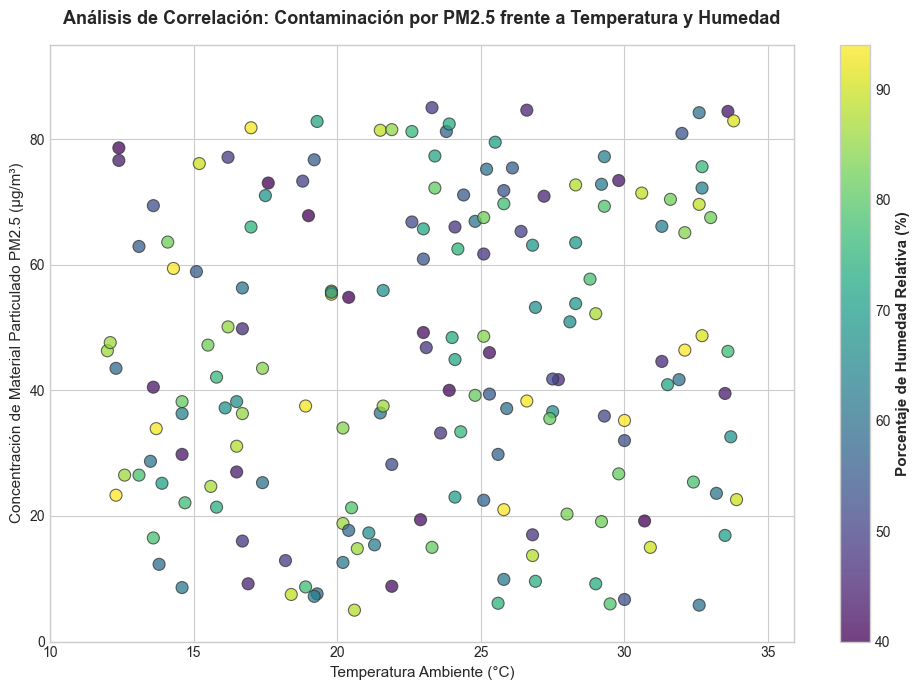

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Configuración de la ruta y carga de datos
ruta_csv = r"C:\Users\marco\Documentos\docencia\fundamentos_de_programacion\2_clases\unidad4\2_datos\contaminacion_ambiental_ciudades.csv"
df_ambiental = pd.read_csv(ruta_csv)

# 2. Pipeline de limpieza previo (Idéntico a las actividades anteriores)
df_ambiental = df_ambiental.dropna(subset=["Ciudad"])
mediana_medellin = df_ambiental[
    (df_ambiental["Ciudad"] == "Medellín") & (df_ambiental["Temperatura_C"] > -40)
]["Temperatura_C"].median()
df_ambiental.loc[
    df_ambiental["Temperatura_C"] == -40.0, "Temperatura_C"
] = mediana_medellin


# =========================================================================
# CONSTRUCCIÓN DEL GRÁFICO DE DISPERSIÓN AVANZADO
# =========================================================================
plt.figure(figsize=(10, 7))

# Seteamos el estilo global
plt.style.use("seaborn-v0_8-whitegrid")

# Requerimiento: Eje X = Temperatura, Eje Y = Nivel_PM25
# Requerimiento: Tercera dimensión -> c = Humedad_Porcentaje usando el mapa de color 'viridis'
# Requerimiento: Opacidad -> alpha = 0.75 para controlar el solapamiento de puntos
dispersion = plt.scatter(
    x=df_ambiental["Temperatura_C"],
    y=df_ambiental["Nivel_PM25"],
    c=df_ambiental["Humedad_Porcentaje"],
    cmap="viridis",
    s=75,  # Tamaño de los marcadores aumentado para mejor visualización
    alpha=0.75,
    edgecolors="#333333",
    linewidths=0.8,
)

# =========================================================================
# PERSONALIZACIÓN Y ELEMENTOS DE REFERENCIA
# =========================================================================
# Añadir títulos y etiquetas con unidades del sistema internacional
plt.title(
    "Análisis de Correlación: Contaminación por PM2.5 frente a Temperatura y Humedad",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Temperatura Ambiente (°C)", fontsize=11)
plt.ylabel("Concentración de Material Particulado PM2.5 (µg/m³)", fontsize=11)

# Requerimiento: Configurar la barra de colores lateral para que la escala sea legible
cbar = plt.colorbar(dispersion)
cbar.set_label(
    "Porcentaje de Humedad Relativa (%)", fontsize=11, fontweight="bold"
)
cbar.ax.tick_params(labelsize=10)

# Ajustar los límites de los ejes para enmarcar la nube de puntos estéticamente
plt.xlim(df_ambiental["Temperatura_C"].min() - 2, df_ambiental["Temperatura_C"].max() + 2)
plt.ylim(0, df_ambiental["Nivel_PM25"].max() + 10)

# Evitar cortes en los bordes antes de mostrar
plt.tight_layout()

# Mostrar gráfico en el cuaderno
plt.show()



# Celda 2 (Markdown): Conclusión Científica e Interpretación de Fenómenos Atmosféricos

*Esta sección contiene el análisis conceptual de alto nivel que el estudiante debe redactar, demostrando que comprende la interacción física de las variables climáticas cruzadas en el gráfico.*

---



# Conclusión Científica Integral: Dinámicas de Interacción Climatológica

Al evaluar la distribución tridimensional de la nube de puntos, donde la posición espacial describe el binomio **Temperatura-Contaminación** y el gradiente cromático añade el factor de **Humedad**, se desprenden las siguientes observaciones científicas y ambientales:

**1. Evaluación de la Tendencia Estructural (Temperatura vs. PM2.5):**
Si observamos una acumulación de puntos con pendientes ascendentes hacia la derecha del gráfico, se confirmaría una **correlación lineal positiva** entre la temperatura y el material particulado. Físicamente, las altas temperaturas en entornos urbanos suelen acelerar las reacciones fotoquímicas en la atmósfera, transformando gases precursores en partículas finas suspendidas secundarias ($PM_{2.5}$). Además, el calor extremo puede inhibir ciertos flujos de viento locales, atrapando la polución a nivel del suelo.



**2. Decodificación de la Tercera Dimensión (El Rol de la Humedad Relativa):**
La barra de color `viridis` mapea los valores de humedad (donde los tonos oscuros/morados representan aire seco y los tonos claros/amarillos indican alta saturación de agua). Al cruzar visualmente el color con la altura del eje $Y$:

* **Condiciones de Alta Peligrosidad (Zona Crítica):** Si los puntos ubicados en la parte más alta del eje $Y$ (niveles alarmantes de PM2.5) muestran predominantemente colores amarillos/claros, significaría que la combinación de calor y alta humedad actúa como un "aglomerante" que mantiene las partículas suspendidas en el aire pesado.
* Por el contrario, si los puntos críticos son de color morado/oscuro, demostraría que los días secos y calurosos son los que disparan las crisis respiratorias, ya que la ausencia de lluvias impide el fenómeno de "lavado atmosférico" (deposición húmeda), permitiendo que el polvo y el hollín floten libremente.

**3. Recomendación de Políticas Públicas basadas en Datos:**
A partir de este análisis multidimensional, se concluye que el comité de alertas tempranas de la red de monitoreo no debe vigilar únicamente las emisiones de las chimeneas o tubos de escape, sino los **pronósticos meteorológicos**. Las ventanas climáticas específicas identificadas en el cuadrante de alta densidad de puntos (ej. días que superen ciertos grados Celsius combinados con rangos específicos de humedad) constituyen el **disparador científico óptimo** para decretar estados de prevención, alertas o emergencias ambientales de manera proactiva, protegiendo la salud pública antes de que los sensores registren picos irreversibles de contaminación.


# Criterios de Evaluación:

* **Criterio de Saneamiento Espacial (25%):** Habilidad del estudiante para entender que la falta de la variable geográfica (`Ciudad`) anula la validez del registro en un estudio regional y aplicar correctamente filtros de eliminación de nulos indexados.
* **Agregaciones Climatológicas (25%):** Uso impecable de la sintaxis de Pandas para obtener múltiples descriptores estadísticos y destreza conceptual interpretando la desviación estándar del PM2.5.
* **Calidad Gráfica y Editorial (25%):** Correcto uso de subgráficos independientes en Matplotlib, rotulado completo de unidades físicas (como °C o g/m³) y exportación automatizada y limpia a PDF.
* **Pensamiento de Ciencia de Datos (25%):** Calidad analítica de la respuesta final. El alumno debe ser capaz de decodificar un scatter plot tridimensional (Eje X, Eje Y y color de puntos por humedad) para emitir un juicio argumentado sobre dinámicas de contaminación ambiental.

### Habilidades a evaluar sobre Gestión de Bases de Datos con SQL

Saber manejar a cabalidad la sentencia `SELECT`

# Parcial 4 – Fundamentos de Programación

**Curso:** Fundamentos de Programación
**Código:** 314029

**Fecha de realización:** **jueves 18 de junio de 2026**
**Horario:** 8:00 a.m. – 10:00 m.
**Duración del parcial:** 2 horas
**Modalidad:** Individual
**Entorno:** Jupyter Notebook
**Valor sugerido:** 20% de la nota final



# Contenidos evaluados

**Capítulos 11, 12 y 13**

# Objetivos del Parcial

* Verificar la capacidad de **visualizar datos** correctamente.
* Integrar conceptos de **análisis de datos** en un caso aplicado.
* Valorar la **interpretación crítica** de resultados.

---



# Estructura del Parcial

| Sección   | Tipo                     | Puntaje  |
| --------- | ------------------------ | -------- |
| I         | Selección múltiple       | 10%      |
| II        | Verdadero / Falso        | 10%      |
| III       | Lectura de código        | 20%      |
| IV        | Análisis conceptual      | 20%      |
| V         | Caso práctico integrador | 40%      |
| **Total** |                          | **100%** |

---



# Preguntas

---

### **Sección I – Selección múltiple (10%)**

**Pregunta 1.**
¿Cuál es una ventaja clave de usar **operaciones vectorizadas** en NumPy?

A. Reducen la claridad del código
B. Son más lentas que los bucles
C. Permiten cálculos más eficientes y compactos
D. Solo funcionan con arreglos unidimensionales

---

# **Sección II – Verdadero / Falso (10%)**

Indique si las afirmaciones son **Verdaderas (V)** o **Falsas (F)**. Justifique brevemente las falsas.

a) `np.mean()` calcula el promedio de un arreglo.
b) Matplotlib solo se usa para gráficos científicos.
c) Un subplot permite mostrar varios gráficos en una misma figura.
d) Un gráfico es una herramienta para comunicar resultados.

---



# **Sección III – Lectura de código (20%)**

Considere el siguiente código:

```python
import numpy as np

datos = np.array([2, 4, 6, 8, 10])
resultado = datos * 2
print(resultado)
```

a) ¿Qué se imprime en pantalla?
b) ¿Qué tipo de operación se realiza sobre `datos`?
c) ¿Por qué esta operación es eficiente en NumPy?

---



### **Sección IV – Análisis conceptual (20%)**

Responda de forma clara:

a) Explique la diferencia entre **análisis descriptivo** y **análisis predictivo**.
b) ¿Por qué la visualización de datos es una etapa clave del análisis?

---



### **Sección V – Caso práctico integrador (40%)**

En una celda de Jupyter Notebook:

1. Cree un arreglo de NumPy con los siguientes datos de temperaturas (°C):

```python
temperaturas = [22, 24, 23, 25, 26, 24, 23]
```

2. Conviértalo en un arreglo de NumPy.
3. Calcule:

   * Temperatura promedio
   * Temperatura máxima
   * Temperatura mínima
4. Genere un **gráfico** (línea o barras) que muestre la evolución de las temperaturas.
5. Escriba una **interpretación corta** (3–4 líneas) de los resultados obtenidos.

---



# Rúbrica de evaluación

| Criterio       | Excelente (5.0)       | Aceptable (3.0)  | Insuficiente (1.0) |
| -------------- | --------------------- | ---------------- | ------------------ |
| Uso de NumPy   | Correcto y eficiente  | Errores leves    | Incorrecto         |
| Visualización  | Clara y bien rotulada | Parcial          | Deficiente         |
| Integración    | Flujo completo        | Flujo incompleto | No integra         |
| Interpretación | Clara y crítica       | Superficial      | Incorrecta         |

---



# Observación didáctica

Este **Parcial 4**:

* Funciona como **cierre natural del curso**.
* Demuestra que el estudiante ya puede **analizar y comunicar datos**.
* Conecta directamente con cursos posteriores de **Data Science y ML**.


# Taller práctico en SQL  

Aquí tienes el script de Python completo para consolidar tus archivos `.csv` limpios dentro de una base de datos relacional SQLite (`.db`).

El script está diseñado para buscar automáticamente los archivos en el directorio que especificaste (`C:\Users\marco\Documentos\docencia\fundamentos_de_programacion\2_clases\unidad4\2_datos\`), aplicarles de forma rápida el **pipeline de limpieza** que estructuramos en los puntos anteriores para evitar guardar datos corruptos, y finalmente guardarlos como tablas independientes dentro de un único archivo llamado `monitoreo_y_gestion.db`.


In [3]:
import os
import sqlite3
import pandas as pd

# 1. Definir la ruta del directorio de trabajo
directorio_datos = r"C:\Users\marco\Documentos\docencia\fundamentos_de_programacion\2_clases\unidad4\2_datos"

# 2. Definir los nombres de los 6 archivos CSV y sus respectivas tablas SQL
archivos_csv = {
    "rendimiento_estudiantes.csv": "rendimiento_estudiantes",
    "ventas_tienda_retail.csv": "ventas_retail",
    "uso_plataforma_streaming.csv": "uso_streaming",
    "indicadores_salud_hospital.csv": "indicadores_salud",
    "desempeño_empleados_rrhh.csv": "desempeño_rrhh",
    "contaminacion_ambiental_ciudades.csv": "contaminacion_ambiental"  # <- AGREGADO: Sexto archivo
}

# 3. Ruta de la base de datos SQL
ruta_base_datos = os.path.join(directorio_datos, "monitoreo_y_gestion.db")

print(f"Iniciando la creación de la base de datos en: {ruta_base_datos}\n")

try:
    # 4. Establecer conexión con SQLite
    conexion = sqlite3.connect(ruta_base_datos)
    cursor = conexion.cursor()

    # 5. Iterar sobre cada archivo para limpiarlo y migrarlo a SQL
    for archivo, nombre_tabla in archivos_csv.items():
        ruta_completa_csv = os.path.join(directorio_datos, archivo)

        # Verificar si el archivo CSV realmente existe en el disco
        if not os.path.exists(ruta_completa_csv):
            print(f"⚠️ Advertencia: No se encontró el archivo '{archivo}'. Se omitirá.")
            continue

        print(f"Procesando '{archivo}'...")
        df = pd.read_csv(ruta_completa_csv)

        # ---------------------------------------------------------------------
        # PIPELINE DE SANEAMIENTO REVISADO (Protección estricta de dtypes)
        # ---------------------------------------------------------------------
        
        # Caso 1: Estudiantes
        if nombre_tabla == "rendimiento_estudiantes":
            df["Nota_Final"] = df["Nota_Final"].astype(float)
            df["Asistencia_Porcentaje"] = df["Asistencia_Porcentaje"].astype(float)
            
            df.loc[df["Nota_Final"] > 5.0, "Nota_Final"] = df.loc[df["Nota_Final"] <= 5.0, "Nota_Final"].median()
            df.loc[df["Horas_Estudio_Semana"] < 0, "Horas_Estudio_Semana"] = 0
            df["Asistencia_Porcentaje"] = df["Asistencia_Porcentaje"].fillna(df["Asistencia_Porcentaje"].median())

        # Caso 2: Ventas Retail
        elif nombre_tabla == "ventas_retail":
            df = df.drop_duplicates()
            df["Precio_Unitario"] = df["Precio_Unitario"].astype(float)
            
            df["Precio_Unitario"] = df.groupby("Categoria_Producto")["Precio_Unitario"].transform(lambda x: x.fillna(x.median()))
            df.loc[df["Cantidad"] > 100, "Cantidad"] = df.loc[df["Cantidad"] <= 100, "Cantidad"].median()
            df["Ingresos_Totales"] = df["Cantidad"] * df["Precio_Unitario"]

        # Caso 3: Streaming
        elif nombre_tabla == "uso_streaming":
            df["Edad"] = df["Edad"].astype(float)
            df["Minutos_Vistos_Mes"] = df["Minutos_Vistos_Mes"].astype(float)
            
            df.loc[df["Edad"] > 100, "Edad"] = df.loc[df["Edad"] <= 100, "Edad"].mean()
            df["Tipo_Suscripcion"] = df["Tipo_Suscripcion"].replace("PREMIUM_ERR", "Premium")
            df.loc[df["Minutos_Vistos_Mes"] < 0, "Minutos_Vistos_Mes"] = 0.0

        # Caso 4: Salud Hospital
        elif nombre_tabla == "indicadores_salud":
            df["Presion_Sistolica"] = df["Presion_Sistolica"].astype(float)
            df["Colesterol_mgDl"] = df["Colesterol_mgDl"].astype(float)
            
            df.loc[df["Presion_Sistolica"] < 40, "Presion_Sistolica"] = df.loc[df["Presion_Sistolica"] >= 40, "Presion_Sistolica"].median()
            df["Colesterol_mgDl"] = df.groupby("Diagnostico_Riesgo")["Colesterol_mgDl"].transform(lambda x: x.fillna(x.median()))

        # Caso 5: Recursos Humanos
        elif nombre_tabla == "desempeño_rrhh":
            df["Salario_Mensual_USD"] = df["Salario_Mensual_USD"].astype(float)
            df["Puntuacion_Evaluacion"] = df["Puntuacion_Evaluacion"].astype(float)
            
            df.loc[df["Salario_Mensual_USD"] > 15000, "Salario_Mensual_USD"] = 7500.0
            df["Puntuacion_Evaluacion"] = df.groupby("Departamento")["Puntuacion_Evaluacion"].transform(lambda x: x.fillna(x.mean()))

        # Caso 6: Contaminación Ambiental  <- AGREGADO: Bloque lógico de curación
        elif nombre_tabla == "contaminacion_ambiental":
            # 1. Purgar filas donde la variable ancla (Ciudad) sea nula
            df = df.dropna(subset=["Ciudad"])
            
            # 2. Forzar variables térmicas y físicas a float64
            df["Temperatura_C"] = df["Temperatura_C"].astype(float)
            df["Nivel_PM25"] = df["Nivel_PM25"].astype(float)
            df["Humedad_Porcentaje"] = df["Humedad_Porcentaje"].astype(float)
            
            # 3. Corregir el outlier de telemetría de -40.0°C usando la mediana local
            # Nota: Agrupamos de forma segura buscando los datos de la ciudad con problemas térmicos
            condicion_error = df["Temperatura_C"] == -40.0
            if condicion_error.any():
                df["Temperatura_C"] = df.groupby("Ciudad")["Temperatura_C"].transform(
                    lambda x: x.replace(-40.0, x[x > -40.0].median())
                )

        # ---------------------------------------------------------------------
        # MIGRACIÓN A LA BASE DE DATOS
        # ---------------------------------------------------------------------
        df.to_sql(nombre_tabla, conexion, if_exists="replace", index=False)
        print(f"   ¡Éxito! Insertadas {len(df)} filas en la tabla SQL '{nombre_tabla}'.")

    conexion.commit()
    print("\n" + "=" * 60)
    print(" BASE DE DATOS SQLITE CREADA Y CONSOLIDADA CON ÉXITO (6 TABLAS)")
    print("=" * 60)

except sqlite3.Error as error:
    print(f"Ocurrió un error al manipular SQLite: {error}")

finally:
    if conexion:
        conexion.close()
        print("Conexión con la base de datos cerrada de forma segura.")

Iniciando la creación de la base de datos en: C:\Users\marco\Documentos\docencia\fundamentos_de_programacion\2_clases\unidad4\2_datos\monitoreo_y_gestion.db

Procesando 'rendimiento_estudiantes.csv'...
   ¡Éxito! Insertadas 120 filas en la tabla SQL 'rendimiento_estudiantes'.
Procesando 'ventas_tienda_retail.csv'...
   ¡Éxito! Insertadas 200 filas en la tabla SQL 'ventas_retail'.
Procesando 'uso_plataforma_streaming.csv'...
   ¡Éxito! Insertadas 150 filas en la tabla SQL 'uso_streaming'.
Procesando 'indicadores_salud_hospital.csv'...
   ¡Éxito! Insertadas 100 filas en la tabla SQL 'indicadores_salud'.
Procesando 'desempeño_empleados_rrhh.csv'...
   ¡Éxito! Insertadas 80 filas en la tabla SQL 'desempeño_rrhh'.
Procesando 'contaminacion_ambiental_ciudades.csv'...
   ¡Éxito! Insertadas 175 filas en la tabla SQL 'contaminacion_ambiental'.

 BASE DE DATOS SQLITE CREADA Y CONSOLIDADA CON ÉXITO (6 TABLAS)
Conexión con la base de datos cerrada de forma segura.



# Ventajas Pedagógicas de esta Solución para tus Clases:

1. **Unificación del Entorno de Datos:** En lugar de hacer que tus estudiantes carguen de forma independiente múltiples archivos planos por toda la computadora, ahora solo deben conectarse a `monitoreo_y_gestion.db`.
2. **Introducción Práctica a SQL en Python:** Este script prepara la clase para introducir librerías de conexión relacional o para realizar consultas directas con Pandas usando comandos como:
```python
df_ventas = pd.read_sql_query(
    "SELECT * FROM ventas_retail WHERE Cantidad > 3", conexion
)

```


3. **Persistencia Garantizada:** Al usar `if_exists='replace'`, si algún estudiante corrompe los datos en memoria mientras practica, solo necesita volver a correr este script para restaurar las tablas limpias de fábrica en un segundo.

# Asignación Wilfram  

Diseño para el **Parcial N° 1 de Fundamentos de Bases de Datos (SQL)**, aplicado exclusivamente a la Tabla 1 (`rendimiento_estudiantes`) de la base de datos relacional `monitoreo_y_gestion.db` que acabamos de estructurar.

Siguiendo tu enfoque pedagógico, el examen tiene una **curva de aprendizaje progresiva** (va sumando una cláusula SQL por cada punto) y está estructurado para que los estudiantes escriban el código SQL y argumenten su interpretación en celdas de tipo *Markdown*.

---



# 📝 PARCIAL 1: FUNDAMENTOS DE CONSULTAS SQL

**Asignatura:** Fundamentos de Programación / Bases de Datos

**Profesor:** Marco Cañas

**Base de Datos Relacional:** `monitoreo_y_gestion.db`

**Tabla de Trabajo:** `rendimiento_estudiantes`

---

### Contexto del Examen: Esquema de la Tabla

Antes de iniciar, recuerda que la tabla `rendimiento_estudiantes` cuenta con los siguientes campos (*columnas*):

* `ID_Estudiante` (Texto)
* `Género` (Texto)
* `Horas_Estudio_Semana` (Entero)
* `Asistencia_Porcentaje` (Entero)
* `Nota_Final` (Decimal)
* `Socioeconómico` (Texto: Bajo, Medio, Alto)

---

### 📌 Punto 1: Estructura Básica de Proyección (10 Puntos)

**Sentencias a evaluar:** `SELECT` y `FROM`

**Enunciado:** La oficina de Registro Académico necesita un listado inicial con la información de contacto e identificación de todo el alumnado de la muestra. Escribe una consulta en SQL que extraiga **únicamente** las columnas correspondientes al identificador del estudiante, su género y su nivel socioeconómico de toda la tabla.

* **Celda de Código SQL:**

```sql
-- Escribe tu consulta aquí

```

* **Celda Markdown (Pregunta de Análisis):** ¿Qué diferencia técnica o de rendimiento existe entre hacer la consulta especificando los nombres de los campos frente al uso del comodín asterisco (`SELECT * FROM...`)? Justifica tu respuesta.

---

### 📌 Punto 2: Filtrado Condicional de Registros (10 Puntos)

**Sentencias a evaluar:** `SELECT`, `FROM` y `WHERE`

**Enunciado:** El departamento de Bienestar Universitario quiere identificar a los estudiantes en situación de vulnerabilidad o riesgo de reprobación. Escribe una consulta en SQL que devuelva el `ID_Estudiante`, las `Horas_Estudio_Semana` y la `Nota_Final` **solo** para aquellos alumnos cuyo nivel `Socioeconómico` sea igual a 'Bajo' **y** que además tengan una `Nota_Final` inferior a 3.0.

* **Celda de Código SQL:**

```sql
-- Escribe tu consulta aquí

```

* **Celda Markdown (Pregunta de Análisis):** Explica el papel que desempeña el operador lógico `AND` dentro de tu cláusula `WHERE` en este escenario y qué ocurriría con los resultados si lo cambiaras por un operador `OR`.

---

### 📌 Punto 3: Agregación y Resumen de Datos (15 Puntos)

**Sentencias a evaluar:** `SELECT`, `FROM`, `WHERE` y `GROUP BY`

**Enunciado:** La decanatura de la facultad está realizando un estudio comparativo del rendimiento académico. Escribe una consulta en SQL que muestre el `Género` y la **nota final promedio** (utiliza la función de agregación `AVG()`) de los estudiantes, agrupados por su género. Sin embargo, para evitar sesgos por inasistencia, la consulta debe incluir **únicamente** a los estudiantes que tengan una `Asistencia_Porcentaje` mayor o igual a 80.

* **Celda de Código SQL:**

```sql
-- Escribe tu consulta aquí

```

* **Celda Markdown (Pregunta de Análisis):** ¿Por qué es obligatorio incluir la columna `Género` tanto en la instrucción `SELECT` como en la instrucción `GROUP BY`? ¿Qué error de consistencia matemática arrojaría el motor de base de datos si la omitieras en el ordenamiento?

---

### 📌 Punto 4: Restricción y Ranking de Resultados (15 Puntos)

**Sentencias a evaluar:** `SELECT`, `FROM`, `WHERE`, `GROUP BY`, `ORDER BY` y `LIMIT`

**Enunciado:** El comité de becas de excelencia académica desea encontrar los mejores promedios de horas de estudio invertidas en los estratos más necesitados. Escribe una consulta en SQL que agrupe a los estudiantes por su nivel `Socioeconómico` y calcule el promedio de `Horas_Estudio_Semana`. Aplica las siguientes restricciones en orden:

1. Filtra para que solo se evalúe a los estudiantes con una `Nota_Final` sobresaliente (mayor o igual a 4.0).
2. Ordena los resultados de manera descendente (`DESC`) según el promedio de horas calculado.
3. Limita la salida para mostrar **únicamente el primer registro** (el estrato con el promedio de estudio más alto).

* **Celda de Código SQL:**

```sql
-- Escribe tu consulta aquí

```

* **Celda Markdown (Pregunta de Análisis):** Describe detalladamente cuál es el **orden lógico de ejecución** que sigue internamente el motor SQL para resolver esta consulta (es decir, qué cláusula se procesa primero en la memoria, cuál segunda, y así sucesivamente hasta el `LIMIT`).

---

### 📌 Punto 5: Reto Práctico Integrador en Python / Pandas (Opcional / Bono de Clase)

**Enunciado:** Abre una celda de código en tu cuaderno de Jupyter y escribe el script de Python necesario para conectarte a la base de datos `monitoreo_y_gestion.db` (usando la librería `sqlite3`). Carga mediante la función `pd.read_sql_query()` la consulta exacta que desarrollaste en el **Punto 3** y almacénala en un DataFrame llamado `df_resultado`. Imprime las filas obtenidas en pantalla.

* **Celda de Código Python:**

```python
# Desarrolla el bloque de conexión y carga con Pandas aquí

```



### 📊 Hoja de Respuestas Esperadas (Para el Profesor):

* **Solución Punto 1:** ```sql
SELECT ID_Estudiante, Género, Socioeconómico FROM rendimiento_estudiantes;
```

```


* **Solución Punto 2:** ```sql
SELECT ID_Estudiante, Horas_Estudio_Semana, Nota_Final
FROM rendimiento_estudiantes
WHERE Socioeconómico = 'Bajo' AND Nota_Final < 3.0;
```

```


* **Solución Punto 3:** ```sql
SELECT Género, AVG(Nota_Final) AS Nota_Promedio
FROM rendimiento_estudiantes
WHERE Asistencia_Porcentaje >= 80
GROUP BY Género;
```

```


* **Solución Punto 4:** ```sql
SELECT Socioeconómico, AVG(Horas_Estudio_Semana) AS Horas_Promedio
FROM rendimiento_estudiantes
WHERE Nota_Final >= 4.0
GROUP BY Socioeconómico
ORDER BY Horas_Promedio DESC
LIMIT 1;
```

```


* **Solución Punto 5 (Python):** ```python
import sqlite3
import pandas as pd
conn = sqlite3.connect(
r"C:\Users\marco\Documentos\docencia\fundamentos_de_programacion\2_clases\unidad4\2_datos\monitoreo_y_gestion.db"
)
query = "SELECT Género, AVG(Nota_Final) FROM rendimiento_estudiantes WHERE Asistencia_Porcentaje >= 80 GROUP BY Género;"
df_resultado = pd.read_sql_query(query, conn)
print(df_resultado)
conn.close()
```

```

# Asignación Pablo  

Aquí tienes el diseño para el **Parcial N° 2 de Fundamentos de Bases de Datos (SQL)**, aplicado de manera exclusiva a la Tabla 2 (`ventas_retail`) de la base de datos relacional `monitoreo_y_gestion.db`.

Al igual que el examen anterior, este parcial mantiene una **curva de aprendizaje estrictamente progresiva**, acumulando una cláusula SQL nueva en cada punto para evaluar la madurez técnica y el criterio de analítica de negocios (*Business Analytics*) de los estudiantes.

---

# 📝 PARCIAL 2: EXTRACCIÓN Y ANALÍTICA DE DATOS COMERCIALES CON SQL

**Asignatura:** Fundamentos de Programación / Bases de Datos

**Profesor:** Marco Cañas

**Base de Datos Relacional:** `monitoreo_y_gestion.db`

**Tabla de Trabajo:** `ventas_retail`

---

### Contexto del Examen: Esquema de la Tabla

La tabla `ventas_retail` registra el histórico de transacciones de la tienda y cuenta con las siguientes columnas:

* `ID_Transaccion` (Texto)
* `Fecha` (Texto/Date)
* `Categoria_Producto` (Texto: Electrónica, Ropa, Hogar, Alimentos)
* `Cantidad` (Entero)
* `Precio_Unitario` (Decimal)
* `Metodo_Pago` (Texto: Tarjeta, Efectivo, Transferencia)
* `Ingresos_Totales` (Decimal: Resultado de Cantidad $\times$ Precio_Unitario)

---

### 📌 Punto 1: Proyección de Atributos de Inventario (10 Puntos)

**Sentencias a evaluar:** `SELECT` y `FROM`

**Enunciado:** El equipo de auditoría interna de la tienda requiere un reporte simplificado para verificar el catálogo de precios cargado en el sistema. Escribe una consulta en SQL que extraiga **únicamente** las columnas correspondientes a la categoría del producto, el precio unitario y el método de pago de todos los registros de la tabla.

* **Celda de Código SQL:**

```sql
-- Escribe tu consulta aquí

```

* **Celda Markdown (Pregunta de Análisis):** Si la tabla tuviera 10 millones de filas y solo necesitas analizar los métodos de pago, ¿por qué se considera una mala práctica de ingeniería de datos escribir `SELECT * FROM ventas_retail`? Explica desde la perspectiva del uso de memoria y ancho de banda.

---

### 📌 Punto 2: Filtrado de Transacciones de Alto Valor (10 Puntos)

**Sentencias a evaluar:** `SELECT`, `FROM` y `WHERE`

**Enunciado:** El departamento de seguridad y prevención de fraudes necesita supervisar las transacciones de montos elevados realizadas en efectivo para cumplir con las regulaciones locales. Escribe una consulta en SQL que devuelva el `ID_Transaccion`, la `Fecha`, la `Categoria_Producto` y los `Ingresos_Totales` **solo** para aquellas ventas de la categoría 'Electrónica' **cuya** vía de pago sea 'Efectivo' **y** cuyos `Ingresos_Totales` superen los 1000.0 dólares.

* **Celda de Código SQL:**

```sql
-- Escribe tu consulta aquí

```

* **Celda Markdown (Pregunta de Análisis):** En la cláusula `WHERE`, ¿qué diferencia matemática y de resultado existiría si por error el estudiante escribe `Ingresos_Totales >= 1000` en lugar de `Ingresos_Totales > 1000`? Justifica la importancia de los operadores relacionales estrictos en auditoría financiera.

---

### 📌 Punto 3: Consolidación y Agregación por Unidades de Negocio (15 Puntos)

**Sentencias a evaluar:** `SELECT`, `FROM`, `WHERE` y `GROUP BY`

**Enunciado:** La gerencia financiera está preparando el cierre contable mensual y desea analizar la liquidez proveniente de pagos digitales. Escribe una consulta en SQL que muestre la `Categoria_Producto` y la **suma total de ingresos generados** (utiliza la función de agregación `SUM(Ingresos_Totales)` renombrada como `Ventas_Totales`) agrupada por cada categoría. Condiciona la consulta para que incluya **únicamente** transacciones donde el `Metodo_Pago` haya sido 'Tarjeta' o 'Transferencia'.

* **Celda de Código SQL:**

```sql
-- Escribe tu consulta aquí

```

* **Celda Markdown (Pregunta de Análisis):** Si ejecutas una función de agregación como `SUM()` o `AVG()` junto a una columna normal (como `Categoria_Producto`), ¿qué función cumple la sentencia `GROUP BY` para evitar que el motor relacional genere un error de inconsistencia en las dimensiones de la tabla resultante?

---

### 📌 Punto 4: Reporte de Rendimiento y Análisis de Competitividad (15 Puntos)

**Sentencias a evaluar:** `SELECT`, `FROM`, `WHERE`, `GROUP BY`, `ORDER BY` y `LIMIT`

**Enunciado:** El director de compras de la cadena de tiendas desea identificar cuál es el producto o categoría líder que registra el ticket o precio promedio de venta más alto, evaluando transacciones de volumen regular. Escribe una consulta en SQL que agrupe los datos por `Categoria_Producto` y calcule el **precio unitario promedio** (usa la función `AVG(Precio_Unitario)`). Aplica los siguientes parámetros:

1. Filtra mediante `WHERE` para evaluar únicamente operaciones donde la `Cantidad` de artículos comprados sea menor o igual a 3 unidades (evitando compras mayoristas atípicas).
2. Ordena los resultados de manera descendente (`DESC`) según el promedio del precio unitario calculado.
3. Restringe el resultado utilizando `LIMIT` para extraer **únicamente la categoría con el promedio más alto**.

* **Celda de Código SQL:**

```sql
-- Escribe tu consulta aquí

```

* **Celda Markdown (Pregunta de Análisis):** Durante el procesamiento de esta consulta, el motor de la base de datos aplica el filtro `WHERE` **antes** de realizar la agrupación con `GROUP BY`. ¿Qué beneficio tiene este orden lógico de ejecución en términos de optimización y velocidad de cálculo en comparación con filtrar los datos después de agruparlos?

---

### 📌 Punto 5: Automatización de Reportes Gerenciales con Pandas (Bono de Clase)

**Enunciado:** Abre una celda de código en tu cuaderno de Jupyter y desarrolla el script de Python necesario para conectarte a la base de datos `monitoreo_y_gestion.db` (usando `sqlite3`). Extrae el reporte estructurado en el **Punto 4** directamente a un DataFrame de Pandas llamado `df_lider_ventas` e imprime el resultado final formateado.

* **Celda de Código Python:**

```python
# Desarrolla el bloque de código de extracción aquí

```

---

### 📊 Hoja de Respuestas Esperadas (Para uso exclusivo del Profesor):

* **Solución Punto 1:**
```sql
SELECT Categoria_Producto, Precio_Unitario, Metodo_Pago FROM ventas_retail;

```


* **Solución Punto 2:**
```sql
SELECT ID_Transaccion, Fecha, Categoria_Producto, Ingresos_Totales 
FROM ventas_retail 
WHERE Categoria_Producto = 'Electrónica' 
  AND Metodo_Pago = 'Efectivo' 
  AND Ingresos_Totales > 1000.0;

```


* **Solución Punto 3:**
```sql
SELECT Categoria_Producto, SUM(Ingresos_Totales) AS Ventas_Totales 
FROM ventas_retail 
WHERE Metodo_Pago = 'Tarjeta' OR Metodo_Pago = 'Transferencia' -- También es válido: WHERE Metodo_Pago IN ('Tarjeta', 'Transferencia')
GROUP BY Categoria_Producto;

```


* **Solución Punto 4:**
```sql
SELECT Categoria_Producto, AVG(Precio_Unitario) AS Precio_Promedio 
FROM ventas_retail 
WHERE Cantidad <= 3 
GROUP BY Categoria_Producto 
ORDER BY Precio_Promedio DESC 
LIMIT 1;

```


* **Solución Punto 5 (Python):**
```python
import sqlite3
import pandas as pd

# Conexión local a la ubicación física de la BD
ruta_db = r"C:\Users\marco\Documentos\docencia\fundamentos_de_programacion\2_clases\unidad4\2_datos\monitoreo_y_gestion.db"
conexion = sqlite3.connect(ruta_db)

# Consulta del Punto 4
query = """
SELECT Categoria_Producto, AVG(Precio_Unitario) AS Precio_Promedio 
FROM ventas_retail 
WHERE Cantidad <= 3 
GROUP BY Categoria_Producto 
ORDER BY Precio_Promedio DESC 
LIMIT 1;
"""

df_lider_ventas = pd.read_sql_query(query, conexion)
print("=== CATEGORÍA LÍDER EN PRECIO PROMEDIO ===")
print(df_lider_ventas)

conexion.close()

```

# Asignación Nicolas  

Aquí tienes el diseño para el **Parcial N° 3 de Fundamentos de Bases de Datos (SQL)**, aplicado de manera exclusiva a la Tabla 3 (`uso_streaming`) de la base de datos relacional `monitoreo_y_gestion.db`.

Manteniendo la coherencia metodológica y la curva de complejidad incremental exigida por tu plan de evaluación, este parcial se enfoca en el área de **Analítica de Productos Digitales y Comportamiento del Usuario (*User Engagement & Retention*)**.

---

# 📝 PARCIAL 3: ANALÍTICA DE PRODUCTOS DIGITALES Y RETENCIÓN CON SQL

**Asignatura:** Fundamentos de Programación / Bases de Datos

**Profesor:** Marco Cañas

**Base de Datos Relacional:** `monitoreo_y_gestion.db`

**Tabla de Trabajo:** `uso_streaming`

---

### Contexto del Examen: Esquema de la Tabla

La tabla `uso_streaming` consolida la actividad mensual de los suscriptores y contiene las siguientes columnas:

* `ID_Usuario` (Texto)
* `Edad` (Decimal)
* `Tipo_Suscripcion` (Texto: Gratuito, Básico, Premium)
* `Minutos_Vistos_Mes` (Decimal)
* `Dispositivo_Principal` (Texto: Smartphone, Tablet, Smart TV, PC)
* `Cancelo_Suscripcion` (Texto: Sí, No)

---

### 📌 Punto 1: Proyección de Atributos de Cuentas de Usuario (10 Puntos)

**Sentencias a evaluar:** `SELECT` y `FROM`

**Enunciado:** El equipo de soporte técnico de la plataforma requiere un reporte básico para auditar la compatibilidad de los entornos de reproducción. Escribe una consulta en SQL que extraiga **únicamente** las columnas correspondientes al identificador del usuario, el tipo de suscripción que posee y su dispositivo principal de todos los registros de la tabla.

* **Celda de Código SQL:**

```sql
-- Escribe tu consulta aquí

```

* **Celda Markdown (Pregunta de Análisis):** Al ejecutar esta consulta, notarás que las filas se muestran en el orden exacto en el que fueron insertadas en el archivo físico. ¿Garantiza una base de datos relacional este orden de manera permanente si no se incluye de forma explícita una cláusula de ordenamiento? Justifica tu respuesta.

---

### 📌 Punto 2: Segmentación de Clientes en Riesgo de Abandono (10 Puntos)

**Sentencias a evaluar:** `SELECT`, `FROM` y `WHERE`

**Enunciado:** El área de retención de clientes (*Customer Success*) busca diseñar una campaña de fidelización dirigida a usuarios jóvenes que están perdiendo el interés en la plataforma y podrían cancelar su cuenta. Escribe una consulta en SQL que devuelva el `ID_Usuario`, la `Edad` y los `Minutos_Vistos_Mes` **solo** para aquellos usuarios cuya `Edad` sea menor de 25 años **y** que registren un consumo de `Minutos_Vistos_Mes` inferior a 120.0 minutos, pero que **aún no** hayan cancelado la suscripción (`Cancelo_Suscripcion = 'No'`).

* **Celda de Código SQL:**

```sql
-- Escribe tu consulta aquí

```

* **Celda Markdown (Pregunta de Análisis):** Explica conceptualmente cómo procesa el motor SQL una cláusula `WHERE` que encadena múltiples condiciones mediante el operador `AND`. ¿Qué ocurre con la evaluación de una fila si la primera condición se cumple pero la segunda resulta falsa?

---

### 📌 Punto 3: Diagnóstico de Consumo por Tipo de Suscripción (15 Puntos)

**Sentencias a evaluar:** `SELECT`, `FROM`, `WHERE` y `GROUP BY`

**Enunciado:** El departamento de infraestructura de servidores necesita medir el tráfico de datos para optimizar el ancho de banda según los niveles de pago de la plataforma. Escribe una consulta en SQL que muestre el `Tipo_Suscripcion` y el **promedio de minutos vistos al mes** (utiliza la función de agregación `AVG(Minutos_Vistos_Mes)` renombrada como `Consumo_Promedio`) agrupado por cada tipo de plan. Restringe la consulta para evaluar **únicamente** a los usuarios que consumen el servicio desde pantallas grandes (`Smart TV` o `PC`).

* **Celda de Código SQL:**

```sql
-- Escribe tu consulta aquí

```

* **Celda Markdown (Pregunta de Análisis):** Si quisieras conocer el promedio de minutos consumidos únicamente para aquellas categorías de suscripción cuyo promedio final supere los 500 minutos, ¿podrías colocar esa restricción dentro del `WHERE` (ej. `WHERE AVG(Minutos_Vistos_Mes) > 500`)? Justifica técnicamente por qué se genera un error de sintaxis y qué cláusula se debería usar en su lugar.

---

### 📌 Punto 4: Identificación del Dispositivo Líder en Pérdida de Clientes (15 Puntos)

**Sentencias a evaluar:** `SELECT`, `FROM`, `WHERE`, `GROUP BY`, `ORDER BY` y `LIMIT`

**Enunciado:** El equipo de desarrollo de aplicaciones (*App Developers*) sospecha que una de sus interfaces de usuario tiene fallas técnicas críticas que provocan altas tasas de deserción. Escribe una consulta en SQL que agrupe los datos por `Dispositivo_Principal` y calcule el **total de usuarios que abandonaron la plataforma** (utiliza la función `COUNT(ID_Usuario)` renombrada como `Total_Bajas`). Aplica los siguientes parámetros:

1. Filtra mediante `WHERE` para incluir únicamente a los registros donde el usuario efectivamente haya cancelado el servicio (`Cancelo_Suscripcion = 'Sí'`).
2. Ordena los resultados de manera descendente (`DESC`) según el conteo de bajas calculado.
3. Restringe el resultado utilizando `LIMIT` para extraer **únicamente el dispositivo que concentra el mayor número de cancelaciones**.

* **Celda de Código SQL:**

```sql
-- Escribe tu consulta aquí

```

* **Celda Markdown (Pregunta de Análisis):** El comando `LIMIT 1` se ejecuta al final de todo el flujo de procesamiento. Si dos dispositivos distintos compartieran exactamente la misma cantidad máxima de cancelaciones (un empate), ¿qué problema analítico se presentaría al usar `LIMIT 1` y qué estrategia de ordenamiento adicional implementarías en el `ORDER BY` para resolverlo de forma determinista?

---

### 📌 Punto 5: Implementación del Reporte en el Pipeline de Python (Bono de Clase)

**Enunciado:** Abre una celda de código en tu cuaderno de Jupyter y desarrolla el script de Python necesario para conectarte a la base de datos `monitoreo_y_gestion.db` (usando `sqlite3`). Carga el reporte estructurado en el **Punto 4** directamente a un DataFrame de Pandas llamado `df_fuga_dispositivo` e imprime el resultado final en pantalla.

* **Celda de Código Python:**

```python
# Desarrolla el bloque de código de extracción aquí

```

---

### 📊 Hoja de Respuestas Esperadas (Para uso exclusivo del Profesor):

* **Solución Punto 1:**
```sql
SELECT ID_Usuario, Tipo_Suscripcion, Dispositivo_Principal FROM uso_streaming;

```


* **Solución Punto 2:**
```sql
SELECT ID_Usuario, Edad, Minutos_Vistos_Mes 
FROM uso_streaming 
WHERE Edad < 25 
  AND Minutos_Vistos_Mes < 120.0 
  AND Cancelo_Suscripcion = 'No';

```


* **Solución Punto 3:**
```sql
SELECT Tipo_Suscripcion, AVG(Minutos_Vistos_Mes) AS Consumo_Promedio 
FROM uso_streaming 
WHERE Dispositivo_Principal = 'Smart TV' OR Dispositivo_Principal = 'PC' -- También es válido: WHERE Dispositivo_Principal IN ('Smart TV', 'PC')
GROUP BY Tipo_Suscripcion;

```


* **Solución Punto 4:**
```sql
SELECT Dispositivo_Principal, COUNT(ID_Usuario) AS Total_Bajas 
FROM uso_streaming 
WHERE Cancelo_Suscripcion = 'Sí' 
GROUP BY Dispositivo_Principal 
ORDER BY Total_Bajas DESC 
LIMIT 1;

```


* **Solución Punto 5 (Python):**
```python
import sqlite3
import pandas as pd

# Conexión a la base de datos centralizada
ruta_db = r"C:\Users\marco\Documentos\docencia\fundamentos_de_programacion\2_clases\unidad4\2_datos\monitoreo_y_gestion.db"
conexion = sqlite3.connect(ruta_db)

# Consulta del Punto 4
query = """
SELECT Dispositivo_Principal, COUNT(ID_Usuario) AS Total_Bajas 
FROM uso_streaming 
WHERE Cancelo_Suscripcion = 'Sí' 
GROUP BY Dispositivo_Principal 
ORDER BY Total_Bajas DESC 
LIMIT 1;
"""

df_fuga_dispositivo = pd.read_sql_query(query, conexion)
print("=== PLATAFORMA CRÍTICA DE DESERCIÓN (CHURN) ===")
print(df_fuga_dispositivo)

conexion.close()

```

# Asignación Cristian  

Diseño para el **Parcial N° 4 de Fundamentos de Bases de Datos (SQL)**, aplicado de manera exclusiva a la Tabla 4 (`indicadores_salud`) de la base de datos relacional `monitoreo_y_gestion.db`.

Siguiendo tu esquema metodológico de complejidad acumulativa cláusula por cláusula, este examen traslada el contexto hacia el ámbito de la **Bioestadística y la Analítica de Datos Clínicos y Epidemiológicos**.




# 📝 PARCIAL 4: EXTRACCIÓN Y DIAGNÓSTICO DE DATOS CLÍNICOS CON SQL

**Asignatura:** Fundamentos de Programación / Bases de Datos

**Profesor:** Marco Cañas

**Base de Datos Relacional:** `monitoreo_y_gestion.db`

**Tabla de Trabajo:** `indicadores_salud`

---

### Contexto del Examen: Esquema de la Tabla

La tabla `indicadores_salud` consolida las métricas e historial de telemetría médica de los pacientes ingresados. Cuenta con las siguientes columnas numéricas y categóricas:

* `ID_Paciente` (Texto)
* `Edad` (Entero)
* `Presion_Sistolica` (Decimal: Medida en mm Hg)
* `Colesterol_mgDl` (Decimal: Medida en mg/dL)
* `Fumador` (Texto: Sí, No)
* `IMC` (Decimal: Índice de Masa Corporal)
* `Diagnostico_Riesgo` (Texto: Bajo, Moderado, Alto)

---

### 📌 Punto 1: Proyección de Atributos del Perfil Clínico (10 Puntos)

**Sentencias a evaluar:** `SELECT` y `FROM`

**Enunciado:** El área de enfermería general requiere generar un listado de control rápido para la ronda matutina. Escribe una consulta en SQL que extraiga **únicamente** las columnas correspondientes al identificador del paciente, su edad y su Índice de Masa Corporal (`IMC`) de todos los registros clínicos almacenados en la tabla.

* **Celda de Código SQL:**

```sql
-- Escribe tu consulta aquí

```

* **Celda Markdown (Pregunta de Análisis):** Al escribir el comando `SELECT ID_Paciente, Edad, IMC`, ¿qué regla del modelo relacional determina el orden de las columnas en la tabla resultante? ¿Es posible alterar el orden físico original en el que fueron creadas las columnas del archivo mediante la sentencia `SELECT`? Justifica tu respuesta.

---

### 📌 Punto 2: Filtrado Epidemiológico de Pacientes Críticos (10 Puntos)

**Sentencias a evaluar:** `SELECT`, `FROM` y `WHERE`

**Enunciado:** El departamento de cardiología preventiva está diseñando un protocolo de intervención de urgencia. Escribe una consulta en SQL que devuelva el `ID_Paciente`, la `Presion_Sistolica` y el `Colesterol_mgDl` **solo** para aquellos pacientes que tengan un hábito de tabaquismo activo (`Fumador = 'Sí'`) **y** que simultáneamente registren una `Presion_Sistolica` estrictamente superior a 140.0 mm Hg (Hipertensión Grado 2).

* **Celda de Código SQL:**

```sql
-- Escribe tu consulta aquí

```

* **Celda Markdown (Pregunta de Análisis):** Si un registro clínico de la tabla posee una presión sistólica de 140.0 mm Hg exactos y el paciente es fumador, ¿aparecerá dicho paciente en el resultado de tu consulta? Justifica detalladamente basándote en el comportamiento de los operadores de comparación.

---

### 📌 Punto 3: Agregación Clínico-Cardiovascular por Estratos de Riesgo (15 Puntos)

**Sentencias a evaluar:** `SELECT`, `FROM`, `WHERE` y `GROUP BY`

**Enunciado:** La dirección epidemiológica del hospital desea evaluar si los niveles de lípidos en la sangre se corresponden de manera estadística con las alertas institucionales. Escribe una consulta en SQL que muestre la columna `Diagnostico_Riesgo` y el **promedio de colesterol** (utiliza la función de agregación `AVG(Colesterol_mgDl)` renombrada bajo el alias `Colesterol_Promedio`) agrupada por cada categoría de diagnóstico. Modifica la consulta para evaluar **únicamente** a los pacientes que sufren de sobrepeso u obesidad (es decir, aquellos con un `IMC` mayor o igual a 25.0).

* **Celda de Código SQL:**

```sql
-- Escribe tu consulta aquí

```

* **Celda Markdown (Pregunta de Análisis):** Explica por qué es metodológicamente incorrecto intentar aplicar el filtro del Índice de Masa Corporal utilizando la sentencia `HAVING` (ej. `HAVING IMC >= 25.0`) en lugar de usar `WHERE`. Establece la diferencia fundamental entre el momento en que actúa `WHERE` y el momento en que actúa `HAVING`.

---

### 📌 Punto 4: Identificación del Grupo de Máxima Alerta en Hipertensión (15 Puntos)

**Sentencias a evaluar:** `SELECT`, `FROM`, `WHERE`, `GROUP BY`, `ORDER BY` y `LIMIT`

**Enunciado:** La junta médica necesita aislar estadísticamente el perfil del paciente que registra la mayor severidad de presión arterial sistólica entre los grupos con hábitos de riesgo consolidados. Escribe una consulta en SQL que agrupe los registros médicos por `Diagnostico_Riesgo` y calcule la **presión sistólica máxima** detectada (utiliza la función `MAX(Presion_Sistolica)` renombrada como `Maxima_Sistolica_Grupo`). Aplica los siguientes parámetros:

1. Filtra mediante `WHERE` para incluir únicamente a los pacientes que pertenecen al grupo de riesgo biológico de la tercera edad (`Edad >= 60`).
2. Ordena los resultados de manera descendente (`DESC`) según la presión máxima calculada.
3. Restringe la salida mediante la cláusula `LIMIT` para extraer **únicamente el grupo que posee el registro de presión más elevado**.

* **Celda de Código SQL:**

```sql
-- Escribe tu consulta aquí

```

* **Celda Markdown (Pregunta de Análisis):** Describe detalladamente el ciclo de vida de los datos durante esta consulta. ¿Qué filas son descartadas en primera instancia en la memoria, sobre cuáles se realiza el cálculo de agrupación y cómo opera finalmente el ordenamiento junto al `LIMIT 1`?

---

### 📌 Punto 5: Extracción Automatizada para Análisis Bioestadístico en Jupyter (Bono)

**Enunciado:** Abre una celda de código en tu cuaderno de Jupyter y desarrolla el script de Python necesario para establecer conexión con la base de datos `monitoreo_y_gestion.db` (usando `sqlite3`). Envía la consulta estructurada en el **Punto 4** directamente a un DataFrame de Pandas llamado `df_alerta_cardiaca` e imprime el resultado final en pantalla.

* **Celda de Código Python:**

```python
# Desarrolla el bloque de código de extracción aquí

```

---



### 📊 Hoja de Respuestas Esperadas (Para uso exclusivo del Profesor):

* **Solución Punto 1:**
```sql
SELECT ID_Paciente, Edad, IMC FROM indicadores_salud;

```


* **Solución Punto 2:**
```sql
SELECT ID_Paciente, Presion_Sistolica, Colesterol_mgDl 
FROM indicadores_salud 
WHERE Fumador = 'Sí' 
  AND Presion_Sistolica > 140.0;

```


* **Solución Punto 3:**
```sql
SELECT Diagnostico_Riesgo, AVG(Colesterol_mgDl) AS Colesterol_Promedio 
FROM indicadores_salud 
WHERE IMC >= 25.0 
GROUP BY Diagnostico_Riesgo;

```


* **Solución Punto 4:**
```sql
SELECT Diagnostico_Riesgo, MAX(Presion_Sistolica) AS Maxima_Sistolica_Grupo 
FROM indicadores_salud 
WHERE Edad >= 60 
GROUP BY Diagnostico_Riesgo 
ORDER BY Maxima_Sistolica_Grupo DESC 
LIMIT 1;

```


* **Solución Punto 5 (Python):**
```python
import sqlite3
import pandas as pd

# Conexión relacional local
ruta_db = r"C:\Users\marco\Documentos\docencia\fundamentos_de_programacion\2_clases\unidad4\2_datos\monitoreo_y_gestion.db"
conexion = sqlite3.connect(ruta_db)

# Consulta formulada en el Punto 4
query = """
SELECT Diagnostico_Riesgo, MAX(Presion_Sistolica) AS Maxima_Sistolica_Grupo 
FROM indicadores_salud 
WHERE Edad >= 60 
GROUP BY Diagnostico_Riesgo 
ORDER BY Maxima_Sistolica_Grupo DESC 
LIMIT 1;
"""

df_alerta_cardiaca = pd.read_sql_query(query, conexion)
print("=== PROTOCOLO DE ALERTA EPIDEMIOLÓGICA MAXIMA ===")
print(df_alerta_cardiaca)

conexion.close()

```

# Asignación Alexander  

Aquí tienes el diseño para el **Parcial N° 5 de Fundamentos de Bases de Datos (SQL)**, aplicado de manera exclusiva a la Tabla 5 (`desempeño_rrhh`) de la base de datos relacional `monitoreo_y_gestion.db`.

Cerrando este ciclo de evaluaciones y respetando la estructura de complejidad acumulativa cláusula por cláusula, el examen se ambienta en el campo corporativo de **Analítica de Recursos Humanos y Gestión del Talento (*People Analytics*)**.

---

# 📝 PARCIAL 5: ANALÍTICA DE RECURSOS HUMANOS Y PEOPLE ANALYTICS CON SQL

**Asignatura:** Fundamentos de Programación / Bases de Datos

**Profesor:** Marco Cañas

**Base de Datos Relacional:** `monitoreo_y_gestion.db`

**Tabla de Trabajo:** `desempeño_rrhh`

---

### Contexto del Examen: Esquema de la Tabla

La tabla `desempeño_rrhh` consolida la estructura de la plantilla de empleados y sus métricas anuales de rendimiento. Cuenta con las siguientes columnas:

* `ID_Empleado` (Texto)
* `Departamento` (Texto: TI, Ventas, RRHH, Finanzas, Operaciones)
* `Anos_Experiencia` (Entero)
* `Salario_Mensual_USD` (Decimal)
* `Puntuacion_Evaluacion` (Decimal: Escala de 1.0 a 5.0)
* `Modalidad` (Texto: Presencial, Remoto, Híbrido)

---

### 📌 Punto 1: Proyección de Atributos de la Nómina (10 Puntos)

**Sentencias a evaluar:** `SELECT` y `FROM`

**Enunciado:** El departamento de nómina y compensaciones requiere exportar una lista básica para auditar los salarios actuales de la compañía. Escribe una consulta en SQL que extraiga **únicamente** las columnas correspondientes al identificador del empleado, su departamento y su salario mensual en dólares de todos los registros de la tabla.

* **Celda de Código SQL:**

```sql
-- Escribe tu consulta aquí

```

* **Celda Markdown (Pregunta de Análisis):** Al ejecutar el comando, notarás que las columnas aparecen exactamente en el orden en que las escribiste en el `SELECT`. Si un analista de datos necesita que en el reporte visual aparezca primero el salario y luego el departamento, ¿se debe modificar el archivo físico de la base de datos o basta con reordenar los campos en la sentencia de proyección? Explica el concepto de independencia de datos.

---

### 📌 Punto 2: Filtrado de Perfiles Clínicos de Alto Rendimiento Remoto (10 Puntos)

**Sentencias a evaluar:** `SELECT`, `FROM` y `WHERE`

**Enunciado:** La dirección general está buscando candidatos internos calificados para liderar un nuevo proyecto de transformación digital que operará bajo teletrabajo. Escribe una consulta en SQL que devuelva el `ID_Empleado`, los `Anos_Experiencia` y la `Puntuacion_Evaluacion` **solo** para aquellos colaboradores que trabajen en la `Modalidad` 'Remoto' **y** que tengan una `Puntuacion_Evaluacion` estrictamente superior a 4.5.

* **Celda de Código SQL:**

```sql
-- Escribe tu consulta aquí

```

* **Celda Markdown (Pregunta de Análisis):** ¿Qué ocurriría con el universo de empleados devuelto si cambias el operador lógico `AND` por un `OR`? Describe el impacto que tendría este cambio en la toma de decisiones del equipo de Recursos Humanos si están buscando perfiles de excelencia que cumplan *ambos* requisitos.

---

### 📌 Punto 3: Análisis del Costo Salarial por Departamentos (15 Puntos)

**Sentencias a evaluar:** `SELECT`, `FROM`, `WHERE` y `GROUP BY`

**Enunciado:** El comité financiero necesita evaluar el presupuesto operativo por departamentos para el próximo año, enfocándose exclusivamente en el personal consolidado. Escribe una consulta en SQL que muestre la columna `Departamento` y el **salario mensual promedio** (utiliza la función de agregación `AVG(Salario_Mensual_USD)` renombrada bajo el alias `Salario_Promedio`) agrupada por cada departamento. Restringe la consulta para evaluar **únicamente** al personal senior o con trayectoria (aquellos empleados con `Anos_Experiencia` mayor o igual a 5 años).

* **Celda de Código SQL:**

```sql
-- Escribe tu consulta aquí

```

* **Celda Markdown (Pregunta de Análisis):** Imaginemos que un estudiante intenta escribir la consulta agregando la cláusula `WHERE Salario_Promedio > 5000` para filtrar los departamentos costosos. Explica técnicamente por qué el motor SQL arrojaría un error al intentar usar un alias o una función de agregación dentro del `WHERE` y qué sentencia se debió utilizar para resolver ese filtrado posterior.

---

### 📌 Punto 4: Identificación del Área con Menor Rendimiento (15 Puntos)

**Sentencias a evaluar:** `SELECT`, `FROM`, `WHERE`, `GROUP BY`, `ORDER BY` y `LIMIT`

**Enunciado:** El equipo de desarrollo organizacional planea diseñar un programa intensivo de capacitación y mentorías dirigido al departamento que registre las métricas de desempeño más preocupantes en el personal operativo. Escribe una consulta en SQL que agrupe los registros de los empleados por `Departamento` y calcule la **puntuación de evaluación promedio** (utiliza la función `AVG(Puntuacion_Evaluacion)` renombrada como `Rendimiento_Promedio`). Aplica los siguientes parámetros:

1. Filtra mediante `WHERE` para incluir únicamente al personal que trabaja bajo la modalidad 'Presencial' (evaluación de infraestructura física).
2. Ordena los resultados de manera **ascendente** (`ASC`) según el rendimiento promedio calculado (para que el promedio más bajo quede en primer lugar).
3. Restringe la salida mediante la cláusula `LIMIT` para extraer **únicamente el departamento con el rendimiento promedio más bajo**.

* **Celda de Código SQL:**

```sql
-- Escribe tu consulta aquí

```

* **Celda Markdown (Pregunta de Análisis):** Explica detalladamente por qué el ordenamiento de los resultados (`ORDER BY`) y la restricción de filas (`LIMIT`) se ejecutan al final del ciclo de procesamiento de la base de datos. ¿Qué problemas de rendimiento ocurrirían si el motor intentara aplicar un `LIMIT` antes de agrupar los datos con el `GROUP BY`?

---

### 📌 Punto 5: Conexión de People Analytics mediante Pandas (Bono de Clase)

**Enunciado:** Abre una celda de código en tu cuaderno de Jupyter y desarrolla el script de Python necesario para establecer conexión con la base de datos `monitoreo_y_gestion.db` (utilizando la librería nativa `sqlite3`). Envía la consulta formulada en el **Punto 4** directamente a un DataFrame de Pandas llamado `df_urgencia_capacitacion` e imprime el resultado final en la pantalla.

* **Celda de Código Python:**

```python
# Desarrolla el bloque de código de extracción aquí

```

---

### 📊 Hoja de Respuestas Esperadas (Para uso exclusivo del Profesor):

* **Solución Punto 1:**
```sql
SELECT ID_Empleado, Departamento, Salario_Mensual_USD FROM desempeño_rrhh;

```


* **Solución Punto 2:**
```sql
SELECT ID_Empleado, Anos_Experiencia, Puntuacion_Evaluacion 
FROM desempeño_rrhh 
WHERE Modalidad = 'Remoto' 
  AND Puntuacion_Evaluacion > 4.5;

```


* **Solución Punto 3:**
```sql
SELECT Departamento, AVG(Salario_Mensual_USD) AS Salario_Promedio 
FROM desempeño_rrhh 
WHERE Anos_Experiencia >= 5 
GROUP BY Departamento;

```


* **Solución Punto 4:**
```sql
SELECT Departamento, AVG(Puntuacion_Evaluacion) AS Rendimiento_Promedio 
FROM desempeño_rrhh 
WHERE Modalidad = 'Presencial' 
GROUP BY Departamento 
ORDER BY Rendimiento_Promedio ASC 
LIMIT 1;

```


* **Solución Punto 5 (Python):**
```python
import sqlite3
import pandas as pd

# Conexión local a la base de datos relacional
ruta_db = r"C:\Users\marco\Documentos\docencia\fundamentos_de_programacion\2_clases\unidad4\2_datos\monitoreo_y_gestion.db"
conexion = sqlite3.connect(ruta_db)

# Consulta estructurada en el Punto 4
query = """
SELECT Departamento, AVG(Puntuacion_Evaluacion) AS Rendimiento_Promedio 
FROM desempeño_rrhh 
WHERE Modalidad = 'Presencial' 
GROUP BY Departamento 
ORDER BY Rendimiento_Promedio ASC 
LIMIT 1;
"""

df_urgencia_capacitacion = pd.read_sql_query(query, conexion)
print("=== DEPARTAMENTO PRIORITARIO PARA CAPACITACIÓN ===")
print(df_urgencia_capacitacion)

conexion.close()

```

# Asigmación Santiago  



# PARCIAL 6: ANALÍTICA CLIMATOLÓGICA Y MONITOREO AMBIENTAL CON SQL

**Asignatura:** Fundamentos de Programación / Bases de Datos

**Profesor:** Marco Cañas

**Base de Datos Relacional:** `monitoreo_y_gestion.db`

**Tabla de Trabajo:** `contaminacion_ambiental`

---



### Contexto del Examen: Esquema de la Tabla

La tabla `contaminacion_ambiental` consolida las lecturas diarias de telemetría de diversas estaciones de monitoreo urbano. Cuenta con las siguientes columnas:

* `ID_Registro` (Texto)
* `Ciudad` (Texto: Bogotá, Medellín, Cali, Barranquilla, Bucaramanga)
* `Nivel_PM25` (Decimal: Concentración de material particulado fino en $\mu g/m^3$)
* `Temperatura_C` (Decimal: Temperatura en grados Celsius)
* `Humedad_Porcentaje` (Decimal: Porcentaje de humedad relativa)
* `Clasificacion_Calidad` (Texto: Buena, Moderada, Dañina)

---

### 📌 Punto 1: Proyección de Atributos de Telemetría (10 Puntos)

**Sentencias a evaluar:** `SELECT` y `FROM`

**Enunciado:** El comité técnico del Ministerio de Ambiente requiere un reporte básico de las condiciones higrotérmicas de las estaciones para calibrar los sensores. Escribe una consulta en SQL que extraiga **únicamente** las columnas correspondientes a la ciudad, la temperatura en grados Celsius y el porcentaje de humedad de todos los registros de la tabla.

* **Celda de Código SQL:**

```sql
-- Escribe tu consulta aquí

```

* **Celda Markdown (Pregunta de Análisis):** Al ejecutar `SELECT Ciudad, Temperatura_C, Humedad_Porcentaje FROM contaminacion_ambiental;`, el motor nos devuelve una matriz de datos. Si la tabla no cuenta con una Clave Primaria (*Primary Key*) explícita, ¿se puede garantizar que dos filas de la consulta no sean exactamente idénticas? Explica el concepto de tuplas duplicadas en el modelo relacional.

---

### 📌 Punto 2: Filtrado de Alertas de Contaminación Crítica (10 Puntos)

**Sentencias a evaluar:** `SELECT`, `FROM` y `WHERE`

**Enunciado:** El sistema de Alertas Tempranas Ambientales necesita aislar los registros donde la calidad del aire representa un peligro inminente para la salud de la población vulnerable. Escribe una consulta en SQL que devuelva el `ID_Registro`, la `Ciudad` y el `Nivel_PM25` **solo** para aquellos días donde la `Clasificacion_Calidad` sea igual a 'Dañina' **y** el `Nivel_PM25` sea estrictamente superior a 55.0 $\mu g/m^3$.

* **Celda de Código SQL:**

```sql
-- Escribe tu consulta aquí

```

* **Celda Markdown (Pregunta de Análisis):** En bases de datos, los valores de tipo texto (cadenas de caracteres) son sensibles a mayúsculas, minúsculas y acentos según la configuración (*Collation*). Si en la base de datos la palabra está guardada como 'Dañina' y en tu cláusula `WHERE` escribes `Clasificacion_Calidad = 'dañina'`, ¿qué problema potencial podría ocurrir en el filtrado?

---

### 📌 Punto 3: Caracterización del Aire por Centros Urbanos (15 Puntos)

**Sentencias a evaluar:** `SELECT`, `FROM`, `WHERE` y `GROUP BY`

**Enunciado:** La Secretaría de Salud Pública está realizando un estudio epidemiológico comparativo y requiere conocer la concentración promedio de partículas finas por región. Escribe una consulta en SQL que muestre la columna `Ciudad` y el **promedio del nivel de PM2.5** (utiliza la función de agregación `AVG(Nivel_PM25)` renombrada bajo el alias `PM25_Promedio`) agrupada por cada ciudad. Restringe la consulta para evaluar **únicamente** los días calurosos (aquellos donde la `Temperatura_C` sea mayor o igual a 28.0).

* **Celda de Código SQL:**

```sql
-- Escribe tu consulta aquí

```

* **Celda Markdown (Pregunta de Análisis):** Describe la diferencia entre el funcionamiento de las funciones de agregación (como `AVG` o `SUM`) y las funciones escalares. ¿Por qué no es posible mezclar libremente una columna no agrupada con una función de agregación en el `SELECT` sin recurrir a la sentencia `GROUP BY`?

---

### 📌 Punto 4: Identificación de la Ciudad con Mayor Sequedad Atmosférica (15 Puntos)

**Sentencias a evaluar:** `SELECT`, `FROM`, `WHERE`, `GROUP BY`, `ORDER BY` y `LIMIT`

**Enunciado:** El cuerpo de bomberos forestales necesita identificar qué zona urbana presenta las condiciones de menor humedad relativa promedio, lo que incrementa el riesgo de propagación de incendios. Escribe una consulta en SQL que agrupe los datos por `Ciudad` y calcule el **porcentaje de humedad promedio** (utiliza la función `AVG(Humedad_Porcentaje)` renombrada como `Humedad_Promedio`). Aplica los siguientes parámetros:

1. Filtra mediante `WHERE` para incluir únicamente los días donde los índices de contaminación fueron aceptables (`Clasificacion_Calidad = 'Buena'`).
2. Ordena los resultados de manera **ascendente** (`ASC`) según la humedad promedio calculada (para que el promedio más seco/bajo quede en primer lugar).
3. Restringe la salida mediante la cláusula `LIMIT` para extraer **únicamente la ciudad con el promedio de humedad más bajo**.

* **Celda de Código SQL:**

```sql
-- Escribe tu consulta aquí

```

* **Celda Markdown (Pregunta de Análisis):** Plantea el escenario físico de la consulta. Si el motor de la base de datos ejecutara la cláusula `LIMIT 1` antes de realizar el ordenamiento `ORDER BY`, ¿el resultado devuelto seguiría siendo el promedio de humedad más bajo de toda la tabla? Justifica por qué el orden jerárquico de las sentencias altera el sentido analítico del reporte.

---

### 📌 Punto 5: Extracción y Consolidación de Datos Ambientales en Python (Bono)

**Enunciado:** Abre una celda de código en tu cuaderno de Jupyter y desarrolla el script de Python necesario para establecer conexión con la base de datos `monitoreo_y_gestion.db` (utilizando la librería nativa `sqlite3`). Carga la consulta estructurada en el **Punto 4** directamente a un DataFrame de Pandas llamado `df_riesgo_incendio` e imprime el resultado en la pantalla.

* **Celda de Código Python:**

```python
# Desarrolla el bloque de código de extracción aquí

```

---

### 📊 Hoja de Respuestas Esperadas (Para uso exclusivo del Profesor):

* **Solución Punto 1:**
```sql
SELECT Ciudad, Temperatura_C, Humedad_Porcentaje FROM contaminacion_ambiental;

```


* **Solución Punto 2:**
```sql
SELECT ID_Registro, Ciudad, Nivel_PM25 
FROM contaminacion_ambiental 
WHERE Clasificacion_Calidad = 'Dañina' 
  AND Nivel_PM25 > 55.0;

```


* **Solución Punto 3:**
```sql
SELECT Ciudad, AVG(Nivel_PM25) AS PM25_Promedio 
FROM contaminacion_ambiental 
WHERE Temperatura_C >= 28.0 
GROUP BY Ciudad;

```


* **Solución Punto 4:**
```sql
SELECT Ciudad, AVG(Humedad_Porcentaje) AS Humedad_Promedio 
FROM contaminacion_ambiental 
WHERE Clasificacion_Calidad = 'Buena' 
GROUP BY Ciudad 
ORDER BY Humedad_Promedio ASC 
LIMIT 1;

```


* **Solución Punto 5 (Python):**
```python
import sqlite3
import pandas as pd

# Conexión local a la base de datos centralizada
ruta_db = r"C:\Users\marco\Documentos\docencia\fundamentos_de_programacion\2_clases\unidad4\2_datos\monitoreo_y_gestion.db"
conexion = sqlite3.connect(ruta_db)

# Consulta estructurada en el Punto 4
query = """
SELECT Ciudad, AVG(Humedad_Porcentaje) AS Humedad_Promedio 
FROM contaminacion_ambiental 
WHERE Clasificacion_Calidad = 'Buena' 
GROUP BY Ciudad 
ORDER BY Humedad_Promedio ASC 
LIMIT 1;
"""

df_riesgo_incendio = pd.read_sql_query(query, conexion)
print("=== URBANO CRÍTICO: MÁXIMO RIESGO DE INCENDIO ===")
print(df_riesgo_incendio)

conexion.close()

```